In [18]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from termcolor import cprint
from pathlib import Path
import pandas as pd
import os
import results_analysis_utils as rutils
import matplotlib.pyplot as plt
import seaborn as sn

%load_ext autoreload
%autoreload 2


# Configuración estética para artículos científicos (Paper-ready)
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['figure.dpi'] = 200 # Alta resolución
plt.rcParams['savefig.dpi'] = 200

one_fish_gt = {"2024_11_12":31.5, "2024_11_28":28.9,"2025_05_08":33.5,"2025_08_21":29.1}

# Choose video day
day_code ="2024_11_28"

# Parámetros Globales
ROOT_DIR = "/home/slimbook/results_fish_sizing/multiple_fish/"+day_code
ASPECT_RATIO_THR = 3.0
ANGLE_THR = 20.0

df=[]

cprint(f"Processing fish videos recorded on the date {day_code} ","blue")
cprint(f"ROOT DIR IS {ROOT_DIR} ","blue")

gt = one_fish_gt[day_code]
cprint(f"✅ Ground Truth is the same for all videos with a single fish: {gt}","magenta")



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Processing fish videos recorded on the date 2024_11_28 
ROOT DIR IS /home/slimbook/results_fish_sizing/multiple_fish/2024_11_28 
✅ Ground Truth is the same for all videos with a single fish: 28.9


In [ ]:
peix_measures={"lubina0":31.5,"peix1":19.4,"caballa":28.9,"peix3":21.6,"lubina2":33.5,"ochoa_no_cinta":30,"ochoa_cinta":33.5,"fake_fish":-100 }


{'13-14-43_0':{},
 '13-16-54_0',
 '13-27-52_0',
 '13-32-16_0',
 '13-34-27_0',
 '13-36-49_0',
 '13-39-00_0',
 '13-41-12_0',
 '13-42-45_0',
 '13-48-24_0',
 '13-49-20_0'}




In [ ]:
gt ={"2024_11_12":
    {'13-14-43_0': {1: "caballa", 21: "fish_3", 24: "caballa", 29: "fish_3", 37: "caballa", 45: "caballa", 58: "fish_3", 62: "fish_3", 75: "fish_3", 77: "fish_3", 81: "fish_3", 82: "fish_3"}},
    
    {'13-16-54_0', {1: "caballa", 12: "fish_3", 17: "fish_3", 29: "fish_3", 41: "caballa", 49: "caballa", 53: "caballa", 59: "fish_3", 67: "fish_3", 68: "fish_3", 70: "caballa", 71: "fish_3"}},
    {'13-27-52_0', {1: "caballa", 2: "caballa", 3: "caballa", 5: "caballa", 6: "caballa", 8: "caballa", 11: "caballa", 12: "caballa", 13: "caballa", 33: "caballa", 35: "caballa", 37: "caballa"} }
}


In [42]:
video_tracks.items()


dict_items([('13-14-43_0', [1, 21, 24, 29, 37, 45, 58, 62, 75, 77, 81, 82]), ('13-16-54_0', [1, 12, 17, 29, 41, 49, 53, 59, 67, 68, 70, 71]), ('13-27-52_0', [1, 2, 3, 5, 6, 8, 11, 12, 13, 33, 35, 37]), ('13-32-16_0', [1, 4, 6, 17, 25, 28, 30, 44, 52, 53, 67]), ('13-34-27_0', [1, 5, 8, 16, 21, 23, 28, 30, 31]), ('13-36-49_0', [1, 2, 3, 6, 10, 11, 19, 20, 24, 30, 33, 40, 41, 42]), ('13-39-00_0', [1, 2, 8, 11, 12, 23]), ('13-41-12_0', [2, 3, 11]), ('13-42-45_0', [1, 2, 5, 17, 26]), ('13-48-24_0', [1, 4, 5, 10]), ('13-49-20_0', [1, 2, 9, 13, 16, 25, 29, 32, 34, 36, 41, 44, 56, 58, 60, 61, 64, 69, 72, 73, 75, 76, 77])])

In [39]:
# 1. Aplicar todos los filtros de calidad de una sola vez
mask_valid = (
    (df_raw_agg["track_id"] != -1) &
    (~df_raw_agg["in_image_borders"]) &
    (df_raw_agg["is_3D_complete"] == True) &
    (df_raw_agg["filtered_length"] > 0) # Mejor > 0 que > -1 para asegurar una medida real
)
df_filtered = df_raw_agg[mask_valid]

# 2. Contar frames por track y quedarse solo con los que tienen más de 5
track_counts = df_filtered.groupby(["video_name", "track_id"]).size()
valid_tracks_df = track_counts[track_counts > 5].reset_index(name="n_frames")

# 3. Crear el diccionario video -> lista de track_ids
video_tracks = valid_tracks_df.groupby("video_name")["track_id"].apply(list).to_dict()

# ==========================================================
# 🚀 4. GENERADOR AUTOMÁTICO DE PLANTILLA GT
# ==========================================================
print("Copia y pega este bloque en tu código para rellenar tu Ground Truth:\n")
print("GROUND_TRUTH = {")
for video, tracks in video_tracks.items():
    print(f"    '{video}': {{")
    for t in sorted(tracks):
        print(f"        {t}: caballa,  ")
    print("    },")
print("}")

Copia y pega este bloque en tu código para rellenar tu Ground Truth:

GROUND_TRUTH = {
    '13-14-43_0': {
        1: caballa,  
        21: caballa,  
        24: caballa,  
        29: caballa,  
        37: caballa,  
        45: caballa,  
        58: caballa,  
        62: caballa,  
        75: caballa,  
        77: caballa,  
        81: caballa,  
        82: caballa,  
    },
    '13-16-54_0': {
        1: caballa,  
        12: caballa,  
        17: caballa,  
        29: caballa,  
        41: caballa,  
        49: caballa,  
        53: caballa,  
        59: caballa,  
        67: caballa,  
        68: caballa,  
        70: caballa,  
        71: caballa,  
    },
    '13-27-52_0': {
        1: caballa,  
        2: caballa,  
        3: caballa,  
        5: caballa,  
        6: caballa,  
        8: caballa,  
        11: caballa,  
        12: caballa,  
        13: caballa,  
        33: caballa,  
        35: caballa,  
        37: caballa,  
    },
    '13-32-1

🔍 Buscando datos RAW en: /home/slimbook/results_fish_sizing/multiple_fish/2024_11_28
📂 Encontrados 11 archivos de resultados.

📊 TOTAL AGREGADO: 6640 líneas de datos.
Number of video seqs is: 11


,video_day,source_folder,video_name,frame_id,class_name,object_id,track_id,is_3D_complete,in_image_borders,does_overlap,...,azimuth_deg,raw_length,filtered_length,spine_length,gt,abs_error_cm,rel_error_%,fish_dist_from_camera,unique_track,failure_reason
0,2024_11_28,13_32_15_13-32-16_0,13-32-16_0,frame_1,0,255,-1,1,False,False,...,-156.819670,0.929948,0.271962,0.260327,33.5,6.303797,18.817303,2.286708,2024_11_28_13_32_15_13-32-16_0--1,angle_fail
1,2024_11_28,13_32_15_13-32-16_0,13-32-16_0,frame_2,0,255,1,1,False,False,...,-1.000000,-1.000000,-1.000000,0.391445,33.5,NaN,NaN,2.289246,2024_11_28_13_32_15_13-32-16_0-1,other
2,2024_11_28,13_32_15_13-32-16_0,13-32-16_0,frame_4,0,255,-1,1,False,False,...,72.726582,0.906084,0.165963,0.164807,33.5,16.903739,50.458923,2.220641,2024_11_28_13_32_15_13-32-16_0--1,angle_fail
3,2024_11_28,13_32_15_13-32-16_0,13-32-16_0,frame_5,0,255,1,1,False,False,...,18.271105,-1.000000,0.213439,0.214062,33.5,12.156142,36.286991,2.229309,2024_11_28_13_32_15_13-32-16_0-1,angle_fail
4,2024_11_28,13_32_15_13-32-16_0,13-32-16_0,frame_6,0,255,3,1,False,False,...,145.739240,1.329281,1.318206,1.274140,33.5,98.320635,293.494433,2.147395,2024_11_28_13_32_15_13-32-16_0-3,angle_fail


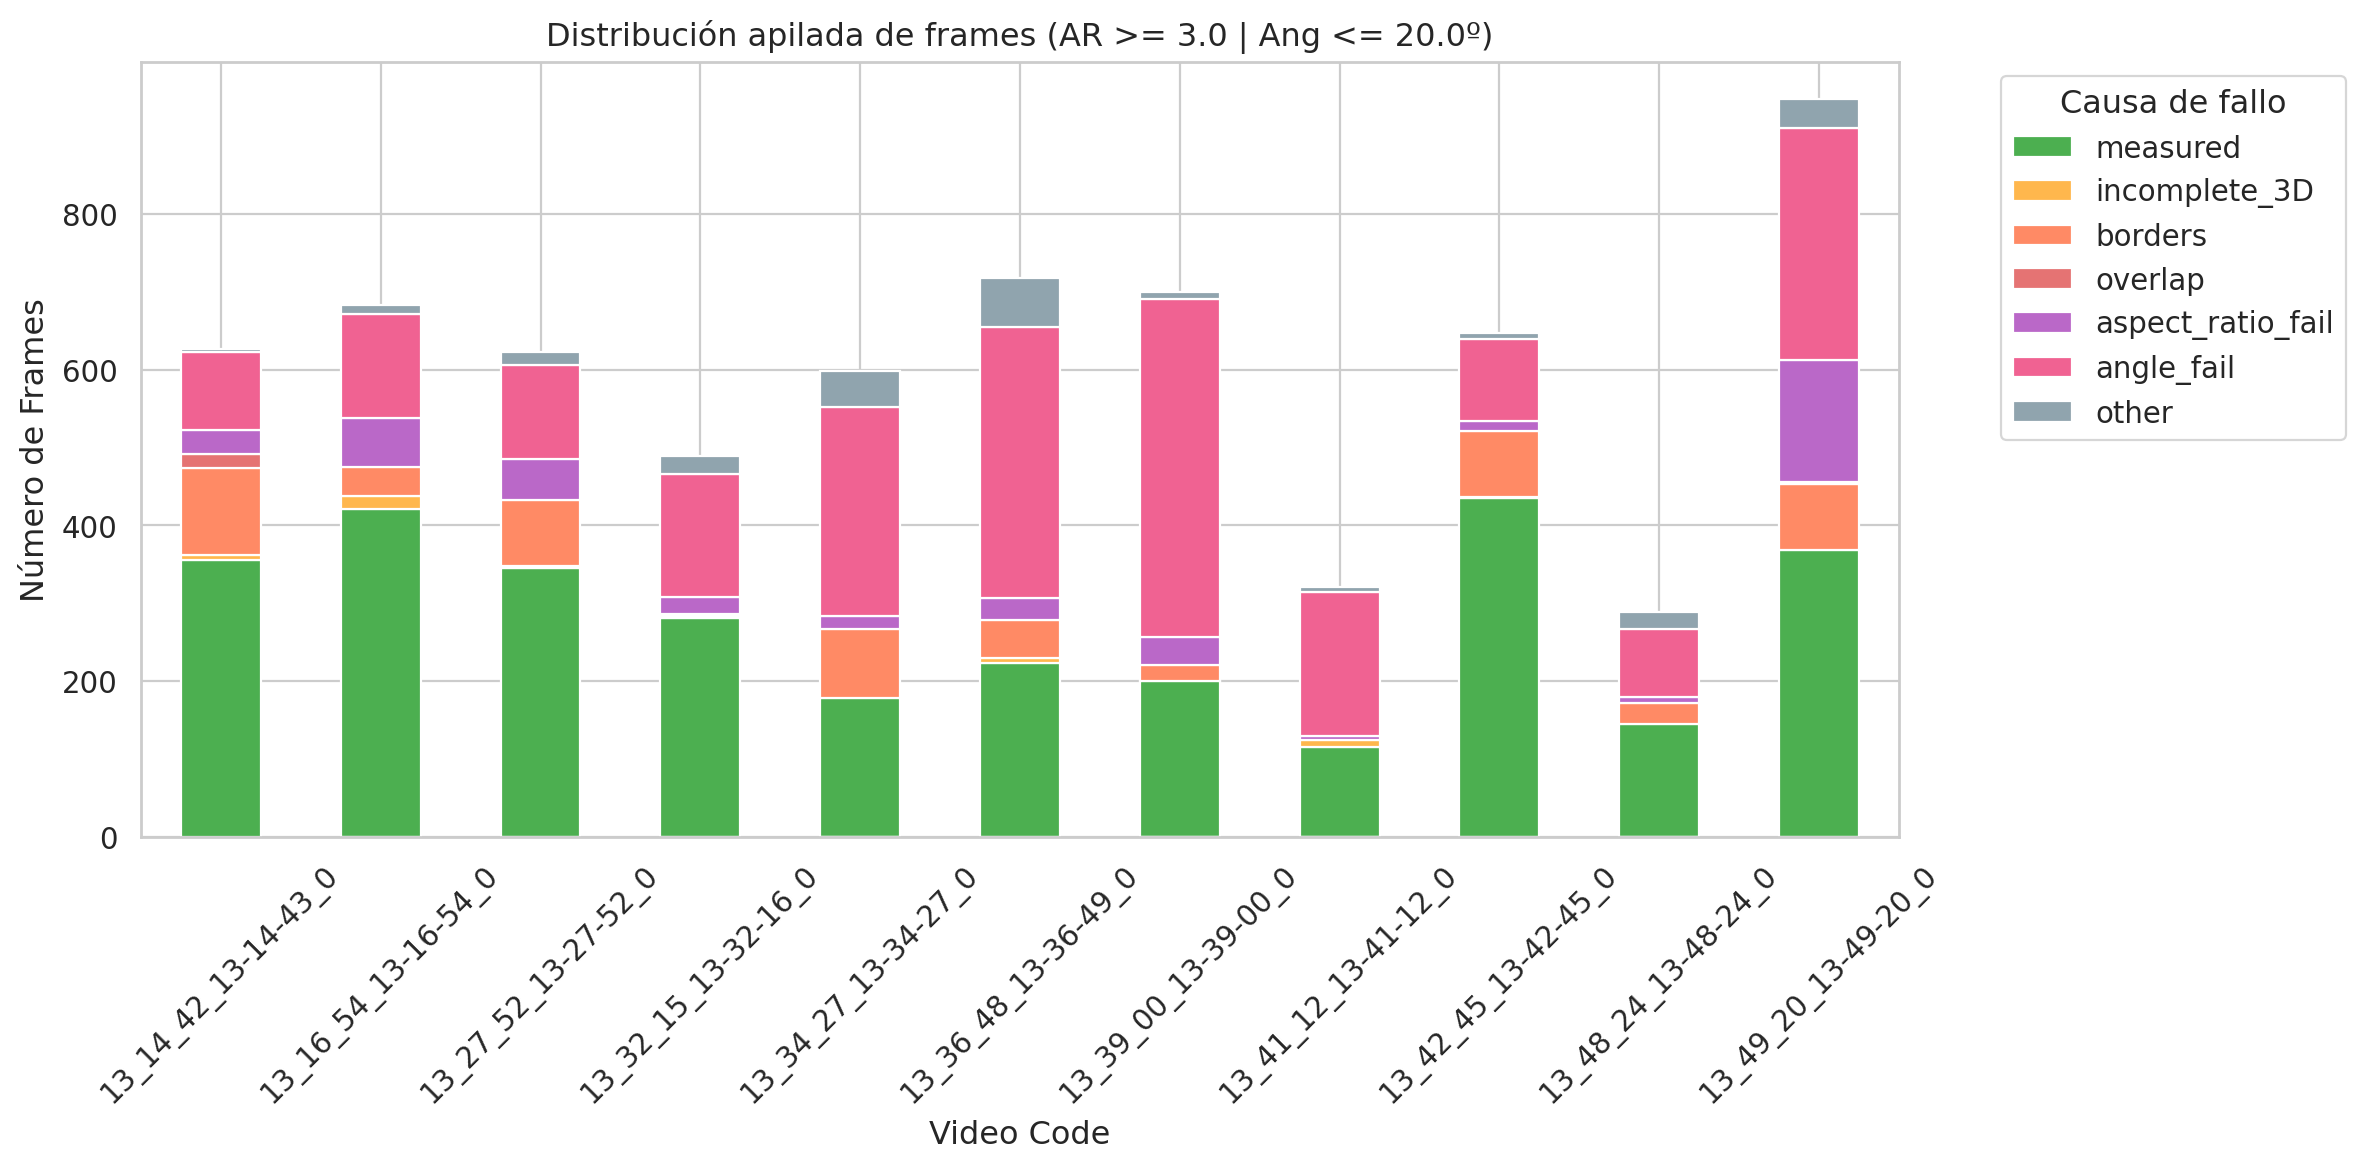

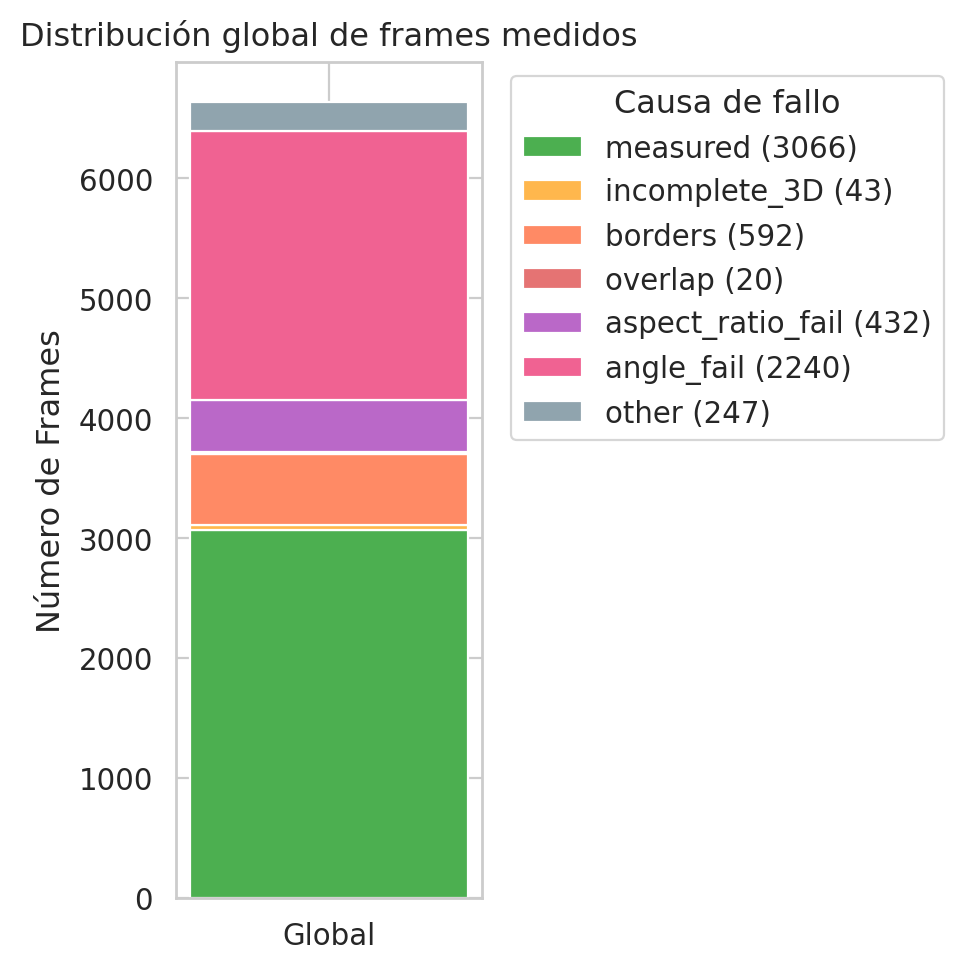


📊 TABLA 1: Distribución Global de Frames


,Causa de Fallo,Cantidad,Porcentaje (%)
0,measured,3066,46.17
1,incomplete_3D,43,0.65
2,borders,592,8.92
3,overlap,20,0.30
4,aspect_ratio_fail,432,6.51
5,angle_fail,2240,33.73
6,other,247,3.72


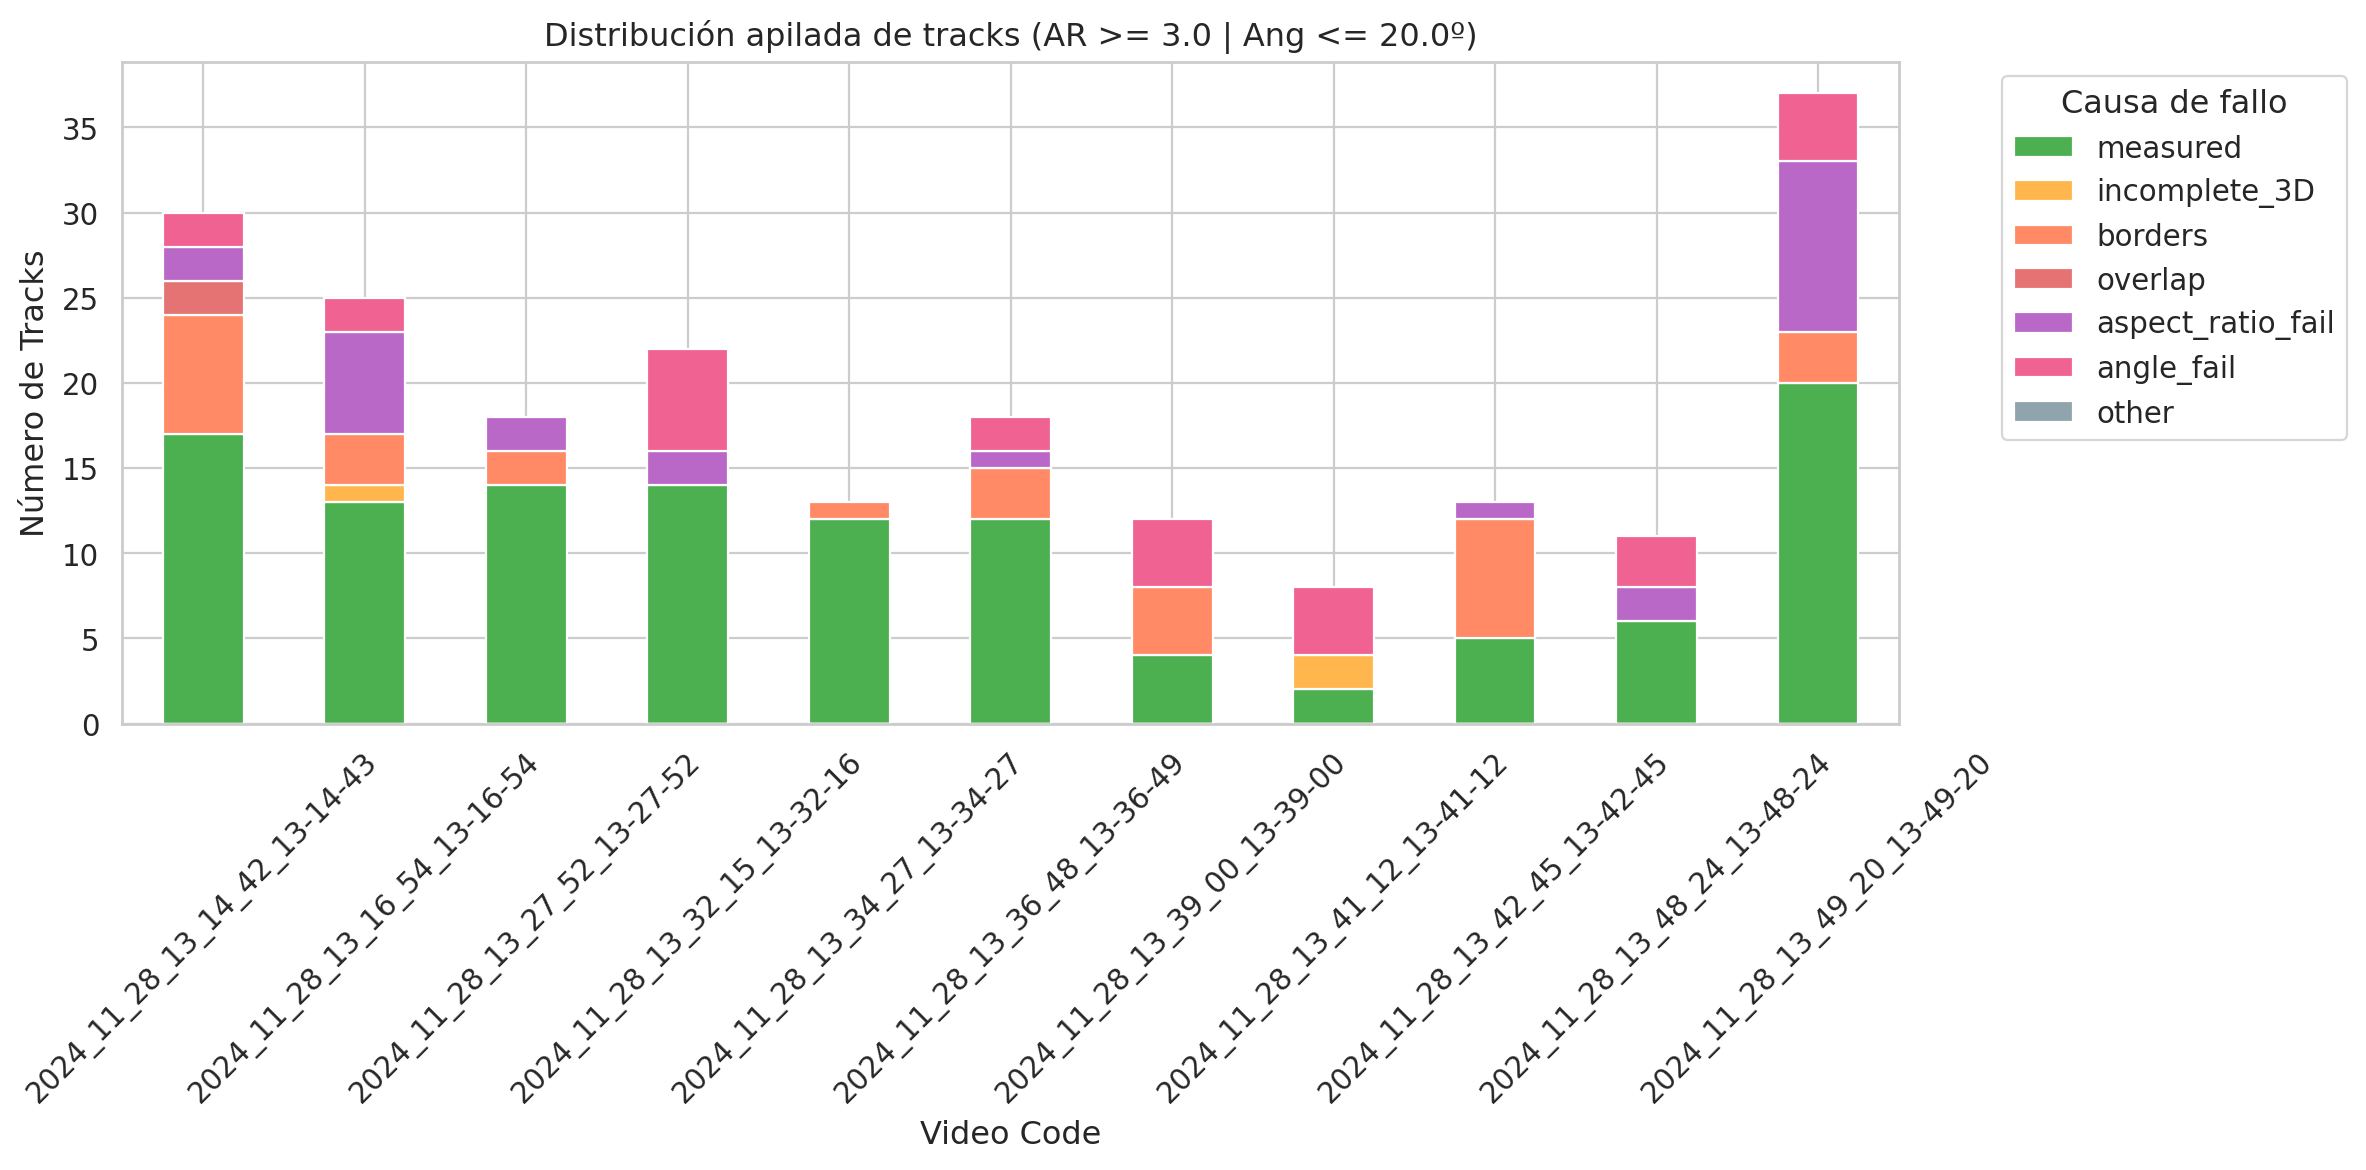

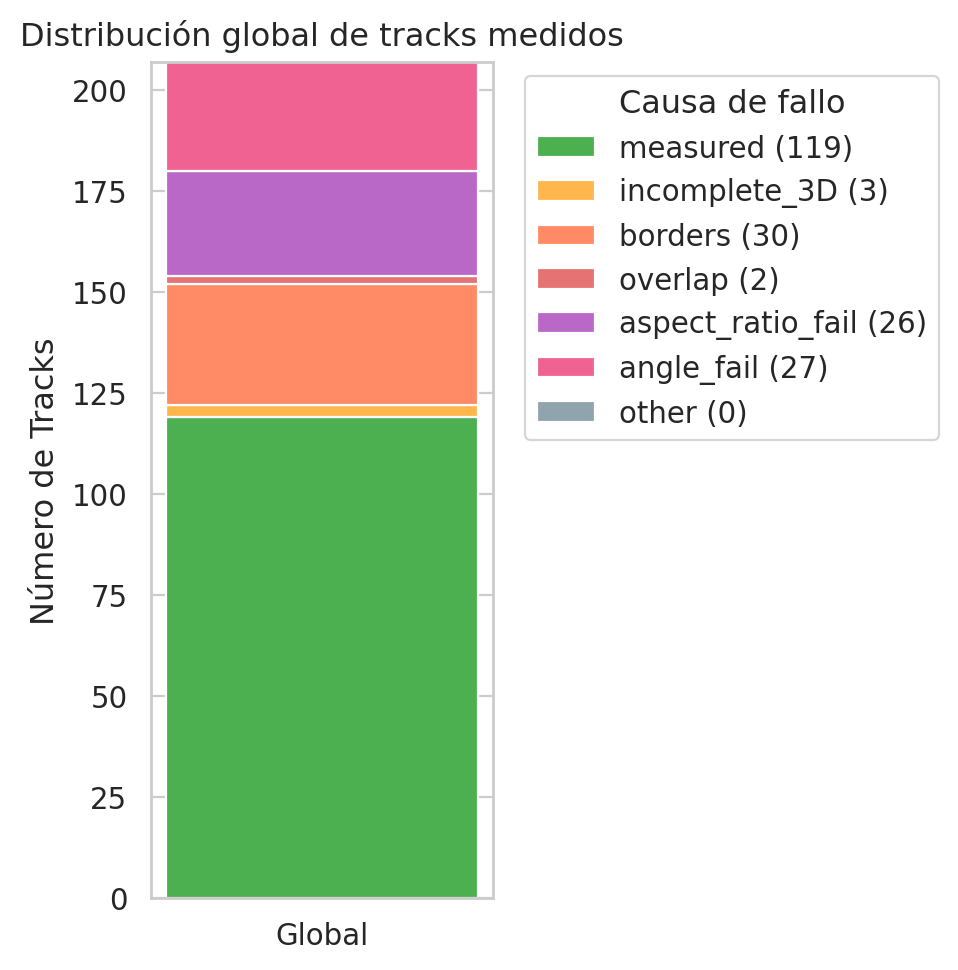


📊 TABLA 1: Distribución Global de Tracks


,Causa de Fallo,Cantidad,Porcentaje (%)
0,measured,119,57.49
1,incomplete_3D,3,1.45
2,borders,30,14.49
3,overlap,2,0.97
4,aspect_ratio_fail,26,12.56
5,angle_fail,27,13.04
6,other,0,0.00



📊 TABLA 2: Desglose por Vídeo


track_failure_reason,measured,incomplete_3D,borders,overlap,aspect_ratio_fail,angle_fail,other
source_folder,,,,,,,
2024_11_28_13_14_42_13-14-43,17,0,7,2,2,2,0
2024_11_28_13_16_54_13-16-54,13,1,3,0,6,2,0
2024_11_28_13_27_52_13-27-52,14,0,2,0,2,0,0
2024_11_28_13_32_15_13-32-16,14,0,0,0,2,6,0
2024_11_28_13_34_27_13-34-27,12,0,1,0,0,0,0
2024_11_28_13_36_48_13-36-49,12,0,3,0,1,2,0
2024_11_28_13_39_00_13-39-00,4,0,4,0,0,4,0
2024_11_28_13_41_12_13-41-12,2,2,0,0,0,4,0
2024_11_28_13_42_45_13-42-45,5,0,7,0,1,0,0


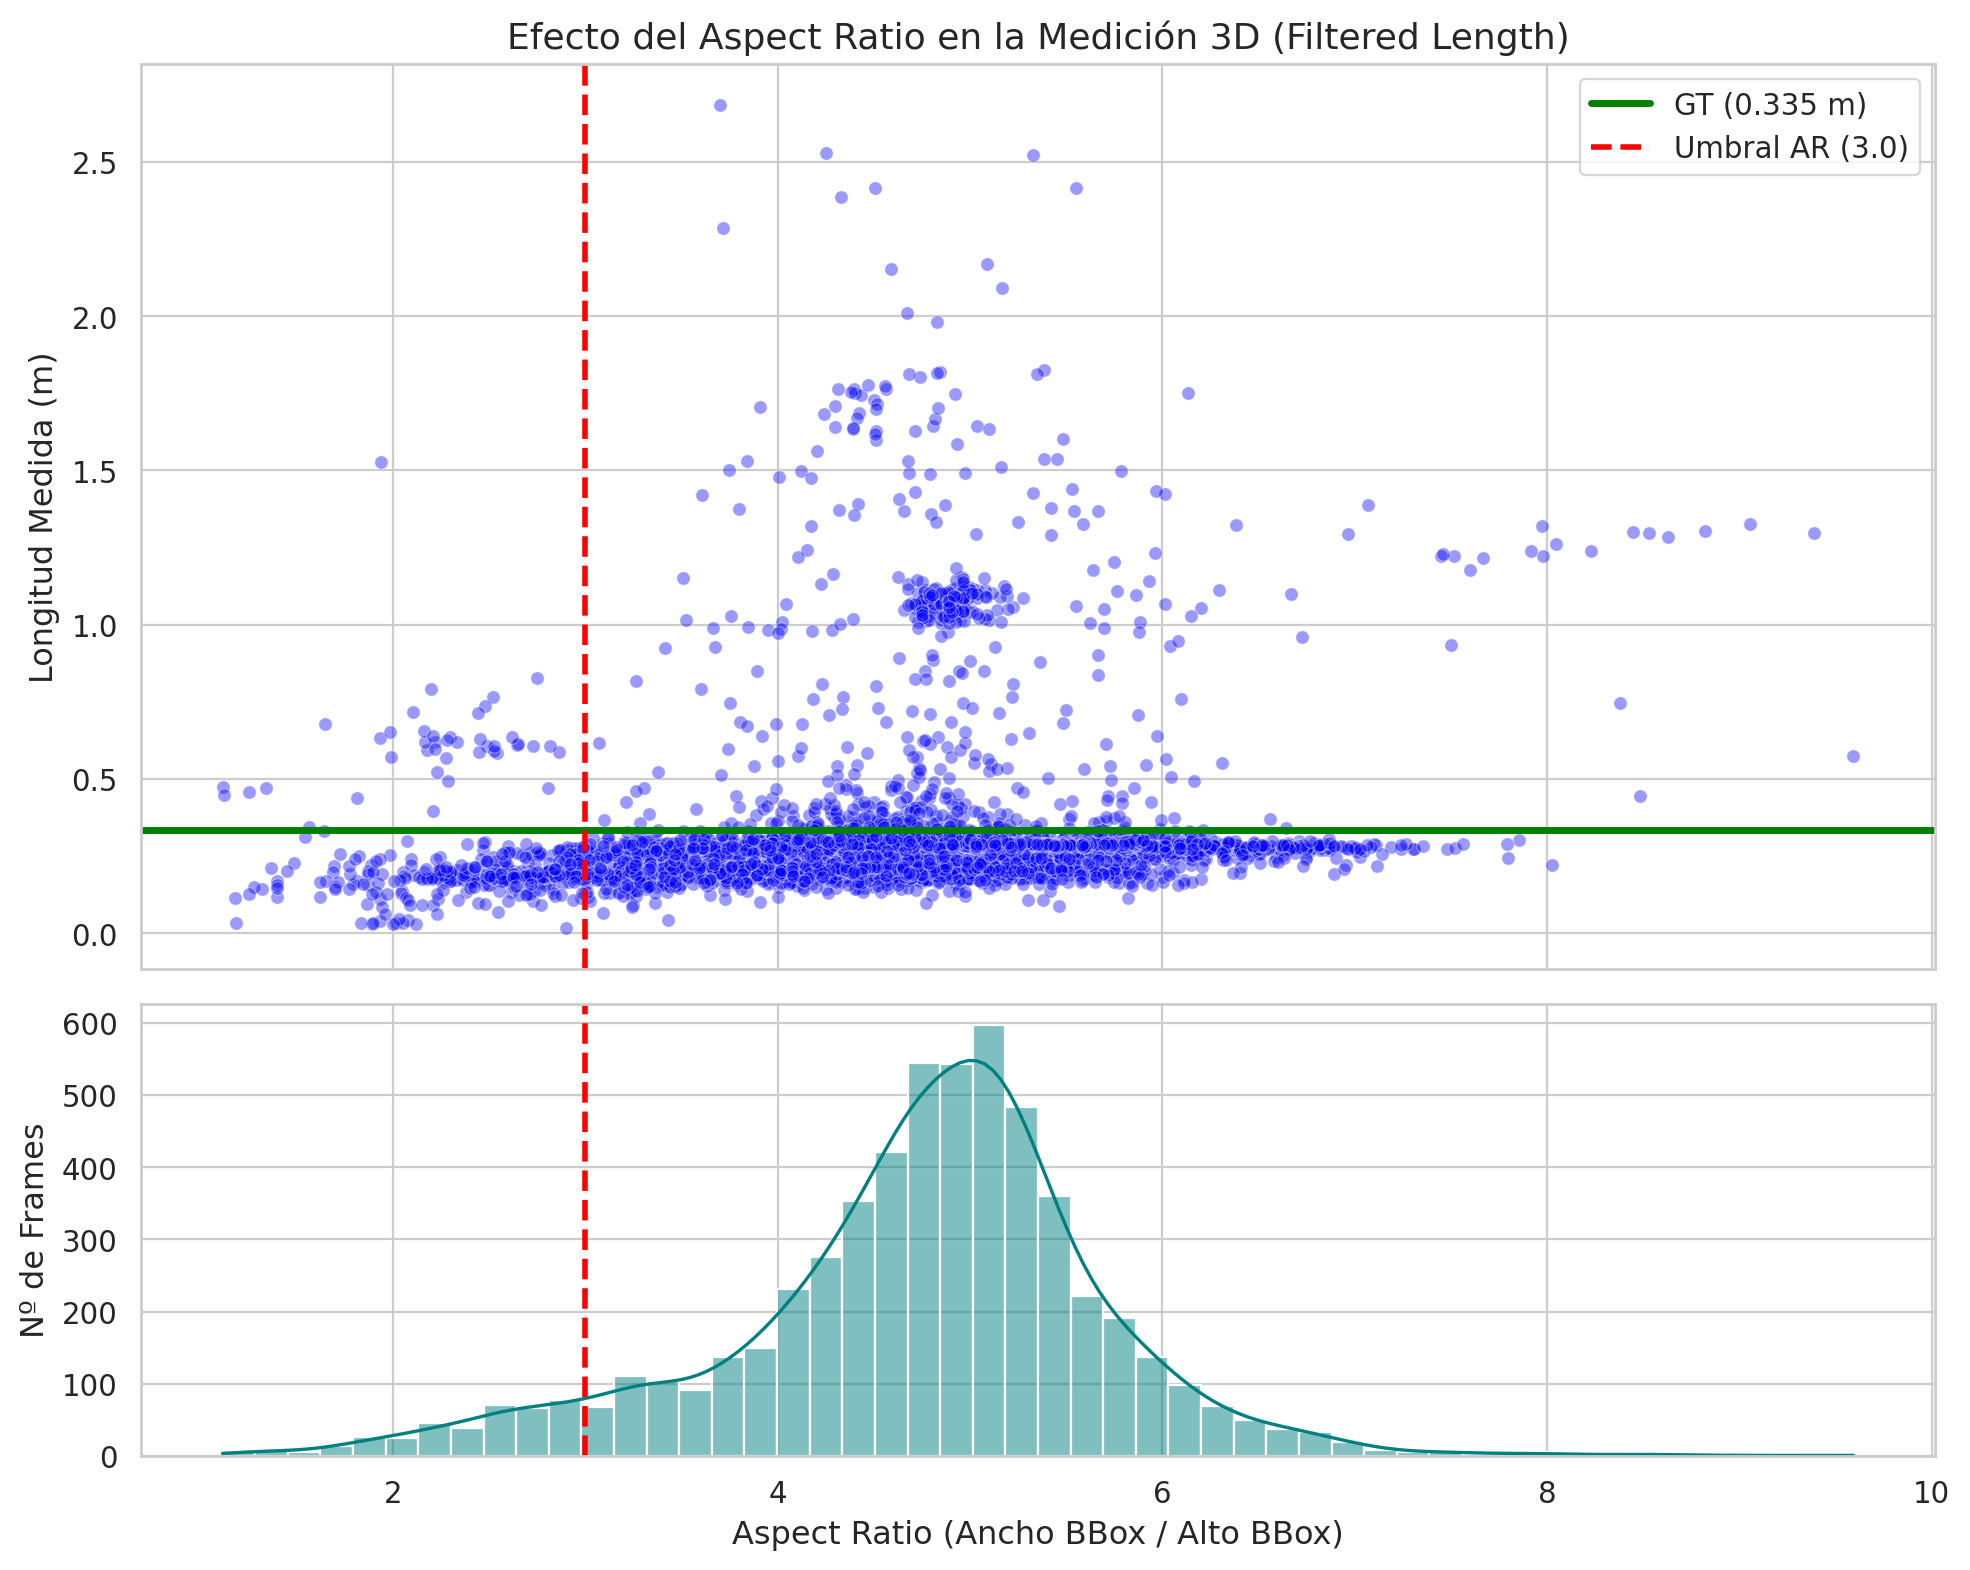

DF NAME IS df_raw_agg
ETAPA DEL PIPELINE (CASCADA)                  | ERROR MEDIO     | FRAMES VIVOS    | PECES (TRACKS)
----------------------------------------------------------------------------------------------------
0. Base (HDBSCAN sin filtros)                 | 11.53 ± 14.55 cm |    5747 frames |   128 tracks
1. + Filtro: Sin Bordes                       | 11.53 ± 14.55 cm |    5747 frames |   128 tracks
2. + Filtro: Sin Solapamiento                 | 11.53 ± 14.60 cm |    5727 frames |   127 tracks
3. + Filtro: Aspect Ratio >= 3.0              | 10.57 ± 15.02 cm |    5339 frames |   113 tracks
4. + Filtro: Ángulo Z <= 20.0º                |  7.08 ± 4.27 cm |    3099 frames |    75 tracks
5. + Filtro: is_3D_complete                   |  6.92 ± 4.12 cm |    3066 frames |    73 tracks


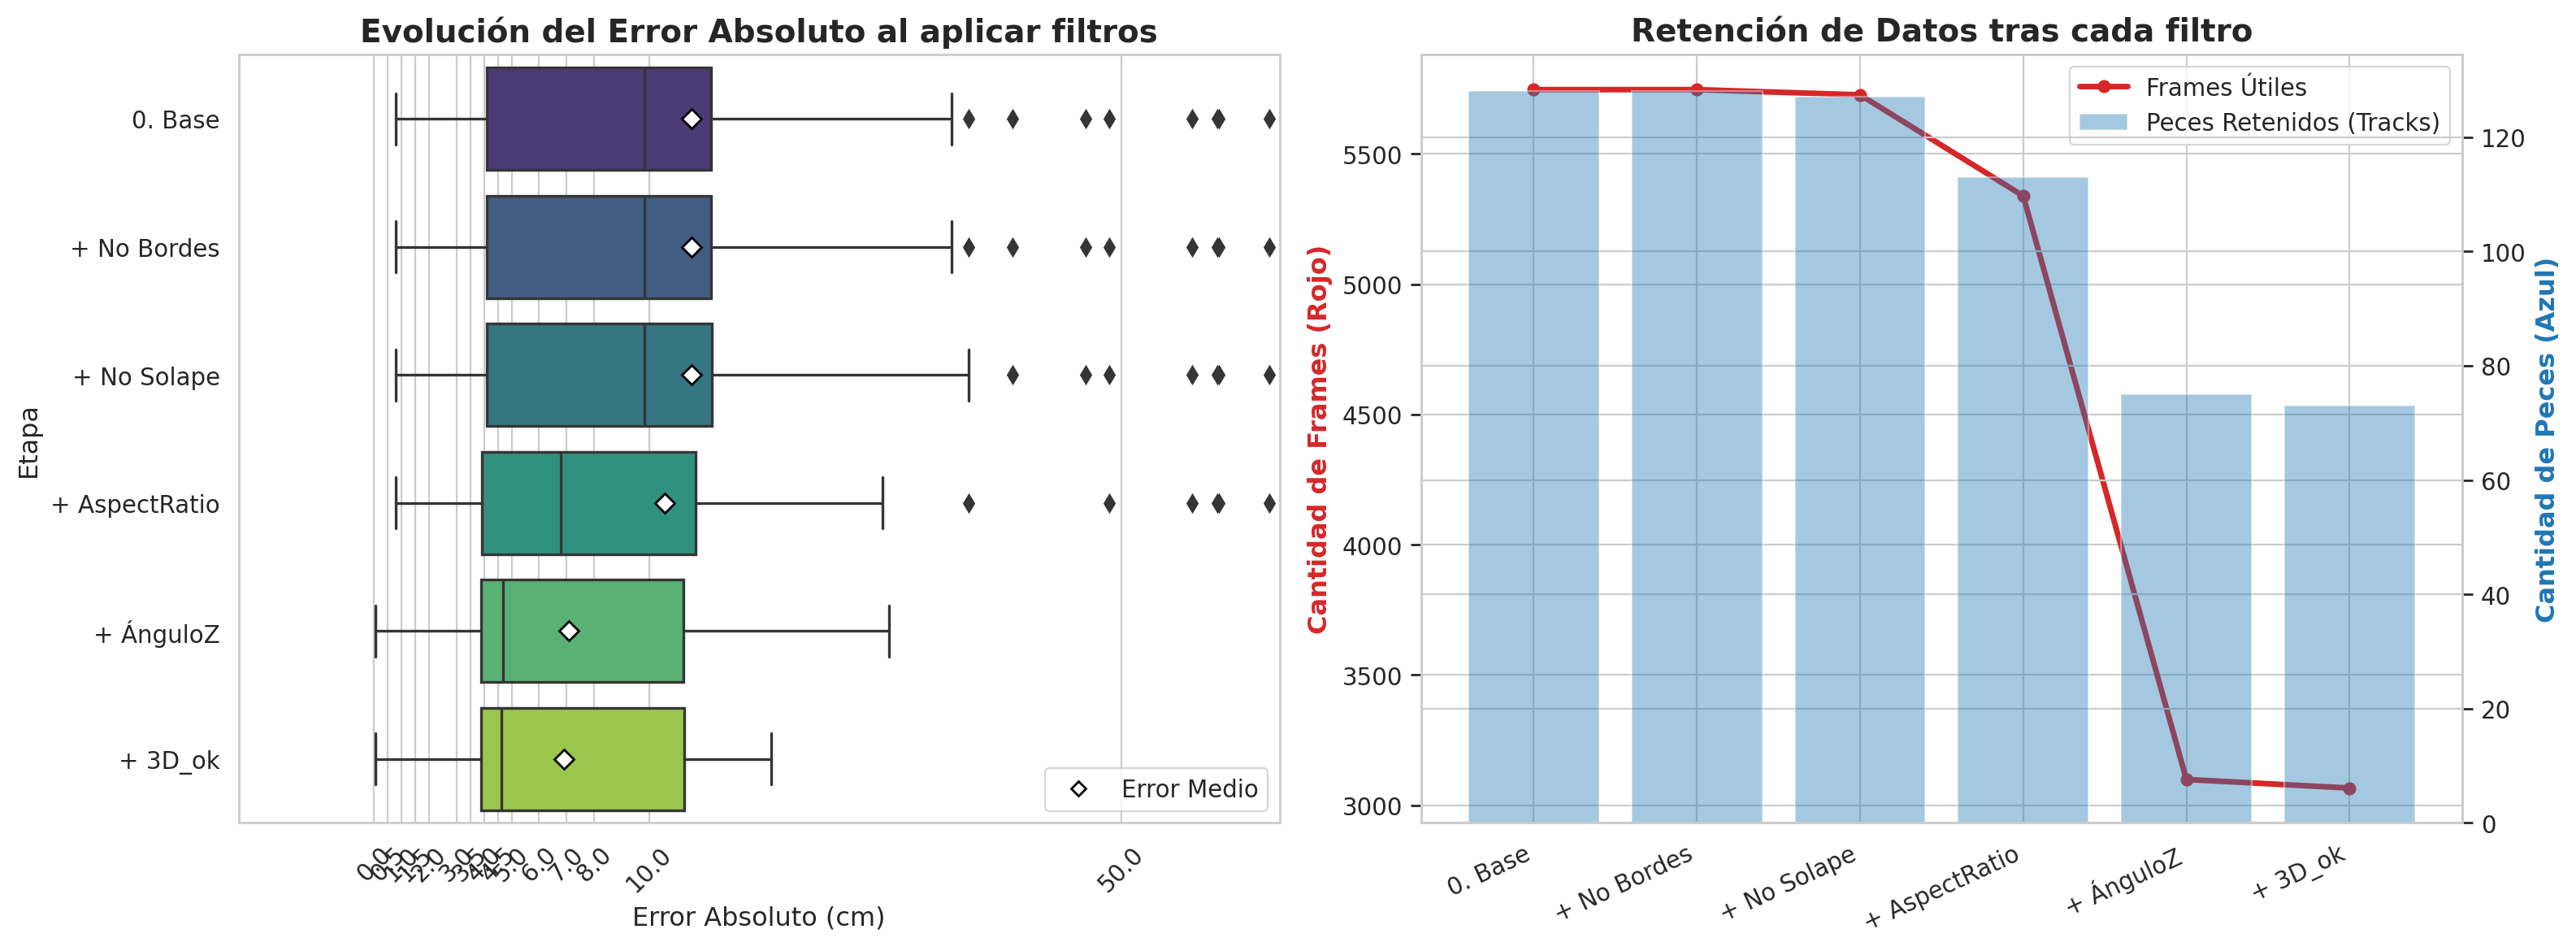

{'0. Base (HDBSCAN sin filtros)':        video_day        source_folder  video_name   frame_id  class_name  \
0     2024_11_28  13_32_15_13-32-16_0  13-32-16_0    frame_1           0   
2     2024_11_28  13_32_15_13-32-16_0  13-32-16_0    frame_4           0   
3     2024_11_28  13_32_15_13-32-16_0  13-32-16_0    frame_5           0   
4     2024_11_28  13_32_15_13-32-16_0  13-32-16_0    frame_6           0   
5     2024_11_28  13_32_15_13-32-16_0  13-32-16_0    frame_8           0   
...          ...                  ...         ...        ...         ...   
6635  2024_11_28  13_16_54_13-16-54_0  13-16-54_0  frame_476           0   
6636  2024_11_28  13_16_54_13-16-54_0  13-16-54_0  frame_477           0   
6637  2024_11_28  13_16_54_13-16-54_0  13-16-54_0  frame_482           0   
6638  2024_11_28  13_16_54_13-16-54_0  13-16-54_0  frame_482           0   
6639  2024_11_28  13_16_54_13-16-54_0  13-16-54_0  frame_483           0   

      object_id  track_id  is_3D_complete  in_image_b

In [22]:
# 1. Cargar y consolidar datos
df_raw_agg = rutils.aggregate_results_from_root(ROOT_DIR, day_code, output_csv_path=None, results_foldername="corrected_results", csv_name="all_fish_info_raw.csv", gt=None)

# 2. Imprimir información de los vídeos
video_codes = df_raw_agg["source_folder"].unique()
cprint(f"Number of video seqs is: {len(video_codes)}", "yellow")
    
# 3. Preparar el ID único del track
df_raw_agg['unique_track'] = df_raw_agg['video_day'].astype(str) + "_" + df_raw_agg['source_folder'].astype(str) +"-"+ df_raw_agg['track_id'].astype(str)

# ==========================================================
# ⚡ 4. CLASIFICACIÓN VECTORIZADA (Súper rápida)
# ¡Aquí creas tu columna física para poder filtrar luego!
# ==========================================================
ASPECT_RATIO_THR = 3.0
ANGLE_THR = 20.0

df_raw_agg = rutils.assign_failure_reasons(
    df_raw_agg, 
    aspect_ratio_thr=ASPECT_RATIO_THR, 
    angle_thr=ANGLE_THR
)

display(df_raw_agg.head()) # Verás que la columna ya está ahí


# ==========================================================
# 5. Generar Gráficas
# ==========================================================

# Las funciones de gráficas leerán esa columna 'failure_reason' que acabas de crear
stacked_frames = rutils.plot_frame_failures(
    df_raw_agg, 
    aspect_ratio_thr=ASPECT_RATIO_THR, 
    angle_thr=ANGLE_THR,
    figsize_video=(12,6), 
    figsize_global=(5,5), 
    show_global=True
)

track_failures = rutils.plot_tracks_failure_distribution(
    df_raw_agg, 
    aspect_ratio_thr=ASPECT_RATIO_THR, 
    angle_thr=ANGLE_THR,
    show_global=True, 
    figsize_video=(12,6), 
    figsize_global=(5,5)
)

rutils.plot_aspect_ratio_vs_length(df_raw_agg, ASPECT_RATIO_THR=ASPECT_RATIO_THR, figsize=(10, 8)) 


df_names = [
    "df_raw_agg"
]

df_results={}
for df_name in df_names:
    df_raw = globals()[df_name]  # <-- toma el DataFrame real
    cprint(f"DF NAME IS {df_name}","cyan")
    stages_dict, agg_stages_dict = rutils.plot_ablation_pipeline(
        df_raw, ASPECT_RATIO_THR=ASPECT_RATIO_THR, ANGLE_THR=ANGLE_THR   
    )
    df_results[df_name] = agg_stages_dict
    
print(stages_dict)

In [21]:
# 1. Extraer el DataFrame agregado de la última etapa (Todos los filtros aplicados)
# El nombre exacto de la llave depende de las variables que le pasaste
ultima_etapa_key = "5. + Filtro: is_3D_complete"
df_final = agg_stages_dict[ultima_etapa_key].copy()

# 2. Eliminar todos los peces con track_id == -1 (Convertimos a string por si acaso)
df_final = df_final[~df_final['track_id'].astype(str).isin(['-1', '-1.0'])]

# 3. Exigir estrictamente que tengan MÁS de 5 frames de track válidos
df_final = df_final[df_final['n_frames_validos'] > 5]

# 4. Crear de nuevo el identificador único para que te sea fácil de leer
df_final['unique_track'] = df_final['video_day'].astype(str) + "_" + df_final['source_folder'].astype(str) + "_" + df_final['track_id'].astype(str)

# 5. Ordenar el dataframe (opcional, para que quede bonito)
df_final = df_final.sort_values(by=['video_day', 'source_folder', 'track_id']).reset_index(drop=True)

# Reordenar las columnas para que el identificador quede primero
cols = ['unique_track', 'video_day', 'source_folder', 'track_id', 'n_frames_validos', 'calculated_length_cm', 'gt_cm', 'abs_error_cm', 'mean_elevation_deg']
df_final = df_final[cols]

cprint(f"🎯 Peces finales válidos y súper filtrados: {len(df_final)}", "green", attrs=["bold"])
display(df_final)

🎯 Peces finales válidos y súper filtrados: 63


,unique_track,video_day,source_folder,track_id,n_frames_validos,calculated_length_cm,gt_cm,abs_error_cm,mean_elevation_deg
0,2024_11_28_13_14_42_13-14-43_0_1,2024_11_28,13_14_42_13-14-43_0,1,34.0,29.753128,33.5,3.746872,-14.853865
1,2024_11_28_13_14_42_13-14-43_0_21,2024_11_28,13_14_42_13-14-43_0,21,22.0,21.716190,33.5,11.783810,-3.179512
2,2024_11_28_13_14_42_13-14-43_0_24,2024_11_28,13_14_42_13-14-43_0,24,21.0,29.173902,33.5,4.326098,-2.270225
3,2024_11_28_13_14_42_13-14-43_0_29,2024_11_28,13_14_42_13-14-43_0,29,38.0,28.916428,33.5,4.583572,-4.996263
4,2024_11_28_13_14_42_13-14-43_0_37,2024_11_28,13_14_42_13-14-43_0,37,11.0,30.584523,33.5,2.915477,-9.987159
...,...,...,...,...,...,...,...,...,...
58,2024_11_28_13_49_20_13-49-20_0_41,2024_11_28,13_49_20_13-49-20_0,41,27.0,20.709772,33.5,12.790228,3.005632
59,2024_11_28_13_49_20_13-49-20_0_58,2024_11_28,13_49_20_13-49-20_0,58,18.0,22.890522,33.5,10.609478,-3.573581
60,2024_11_28_13_49_20_13-49-20_0_61,2024_11_28,13_49_20_13-49-20_0,61,6.0,20.161826,33.5,13.338174,8.657564
61,2024_11_28_13_49_20_13-49-20_0_64,2024_11_28,13_49_20_13-49-20_0,64,24.0,23.826989,33.5,9.673011,4.809210


In [ ]:
df_base_noviembre = df_results["df_raw_agg_2025_05_08"]["5. + Filtro: is_3D_complete"]

display(df_base_noviembre.sort_values(by='abs_error_cm', ascending=False))

In [ ]:

# folder_code ="2024_11_12"
# ROOT_DIR = "/home/slimbook/fish_sizing/ARTICLE/1_peix/"+folder_code

# df_raw_agg_2024_11_12 =rutils.create_df_from_root_folders(root_dir= ROOT_DIR,folder_code =folder_code, output_csv_path=ROOT_DIR ,results_dir="corrected_results", gt=one_fish_gt[folder_code])

# folder_code ="2024_11_28"
# ROOT_DIR = "/home/slimbook/fish_sizing/ARTICLE/1_peix/"+folder_code
# df_raw_agg_2024_11_28 = rutils.create_df_from_root_folders(root_dir= ROOT_DIR,folder_code =folder_code, output_csv_path=ROOT_DIR ,results_dir="corrected_results", gt=one_fish_gt[folder_code])


# folder_code ="2025_05_08"
# ROOT_DIR = "/home/slimbook/fish_sizing/ARTICLE/1_peix/"+folder_code
# df_raw_agg_2025_05_08 = rutils.create_df_from_root_folders(root_dir= ROOT_DIR,folder_code =folder_code, output_csv_path=ROOT_DIR ,results_dir="corrected_results", gt=one_fish_gt[folder_code])

# # Lista de DataFrames
# dfs = [
#     df_raw_agg_2024_11_12,
#     df_raw_agg_2024_11_28,
#     df_raw_agg_2025_05_08
# ]

# # Concatenar verticalmente (apilarlos)
# df_raw_agg_pool = pd.concat(dfs, axis=0, ignore_index=True)

# # Revisar
# print(df_raw_agg_pool.shape)
# print(df_raw_agg_pool.head())

# folder_code ="2025_08_21"
# ROOT_DIR = "/home/slimbook/fish_sizing/ARTICLE/1_peix/"+folder_code
# df_raw_agg_2025_08_21 = rutils.create_df_from_root_folders(root_dir= ROOT_DIR,folder_code =folder_code, output_csv_path=ROOT_DIR ,results_dir="corrected_results", gt=one_fish_gt[folder_code])


# df_raw_agg_2025_08_21.head()



Buscando datos RAW en: /home/slimbook/fish_sizing/ARTICLE/1_peix/2024_11_12
Procesando csv:  /home/slimbook/fish_sizing/ARTICLE/1_peix/2024_11_12/10_44_11/0/results_article_basic_nou/corrected_results/10_44_11_0_raw.csv
FOLDER CODE IS:  2024_11_12
Procesando csv:  /home/slimbook/fish_sizing/ARTICLE/1_peix/2024_11_12/10_54_07/0/results_article_basic_nou/corrected_results/10_54_07_0_raw.csv
FOLDER CODE IS:  2024_11_12
Procesando csv:  /home/slimbook/fish_sizing/ARTICLE/1_peix/2024_11_12/11_10_50/0/results_article_basic_nou/corrected_results/11_10_50_0_raw.csv
FOLDER CODE IS:  2024_11_12
Procesando csv:  /home/slimbook/fish_sizing/ARTICLE/1_peix/2024_11_12/11_00_27/0/results_article_basic_nou/corrected_results/11_00_27_0_raw.csv
FOLDER CODE IS:  2024_11_12
Procesando csv:  /home/slimbook/fish_sizing/ARTICLE/1_peix/2024_11_12/10_58_20/0/results_article_basic_nou/corrected_results/10_58_20_0_raw.csv
FOLDER CODE IS:  2024_11_12
Procesando csv:  /home/slimbook/fish_sizing/ARTICLE/1_peix/2024_

,video_day,source_folder,frame_id,class_name,object_id,track_id,is_3D_complete,in_image_borders,does_overlap,is_front_fish,...,fish_direction,elevation_deg,azimuth_deg,raw_length,filtered_length,spine_length,gt,abs_error_cm,rel_error_%,fish_dist_from_camera
0,2025_08_21,12_09_03_compressed,frame_0,0,255,1,-1,False,False,True,...,NaN,67.619721,37.106544,-1.0,0.322840,0.316668,29.1,3.184030,11.709446,1.663082
1,2025_08_21,12_09_03_compressed,frame_1,0,255,1,-1,False,False,True,...,NaN,66.080659,37.133779,-1.0,0.308119,0.328139,29.1,1.711855,6.615414,1.659265
2,2025_08_21,12_09_03_compressed,frame_2,0,255,1,-1,False,False,True,...,NaN,50.109826,25.106295,-1.0,0.249701,0.228324,29.1,4.129863,13.598142,1.693085
3,2025_08_21,12_09_03_compressed,frame_3,0,255,1,-1,False,False,True,...,NaN,58.247246,14.057908,-1.0,0.300613,0.282332,29.1,0.961328,4.018435,1.678158
4,2025_08_21,12_09_03_compressed,frame_4,0,255,1,-1,False,False,True,...,NaN,44.696387,13.541004,-1.0,0.257552,0.244369,29.1,3.344761,10.881526,1.710066


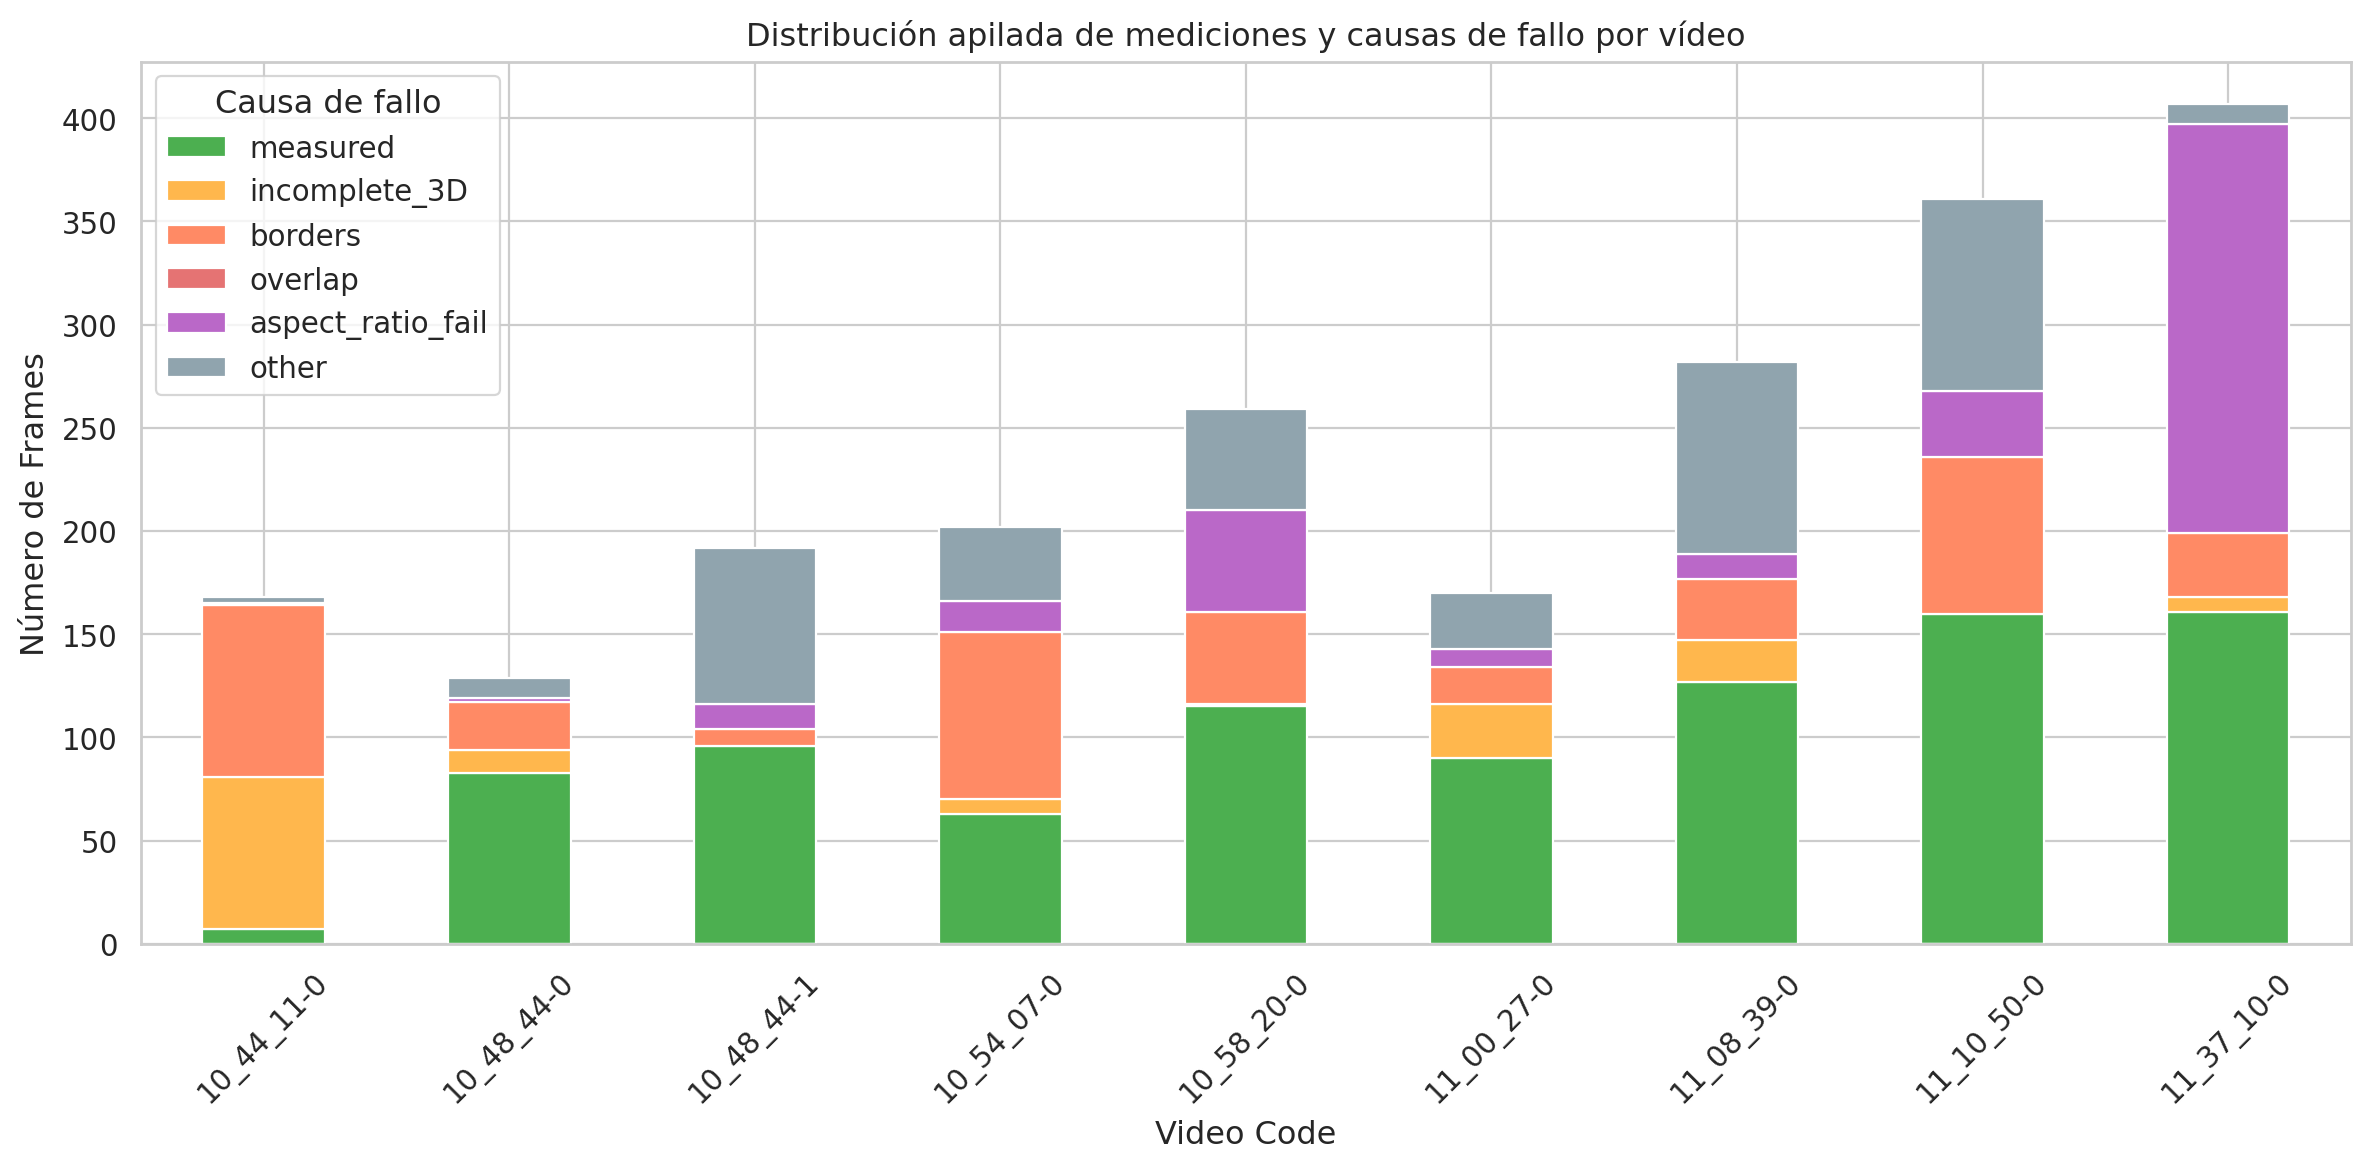

Conteo global de frames por causa:
      failure_reason  count
0           measured    902
1      incomplete_3D    146
2            borders    395
3            overlap      0
4  aspect_ratio_fail    330
5              other    397


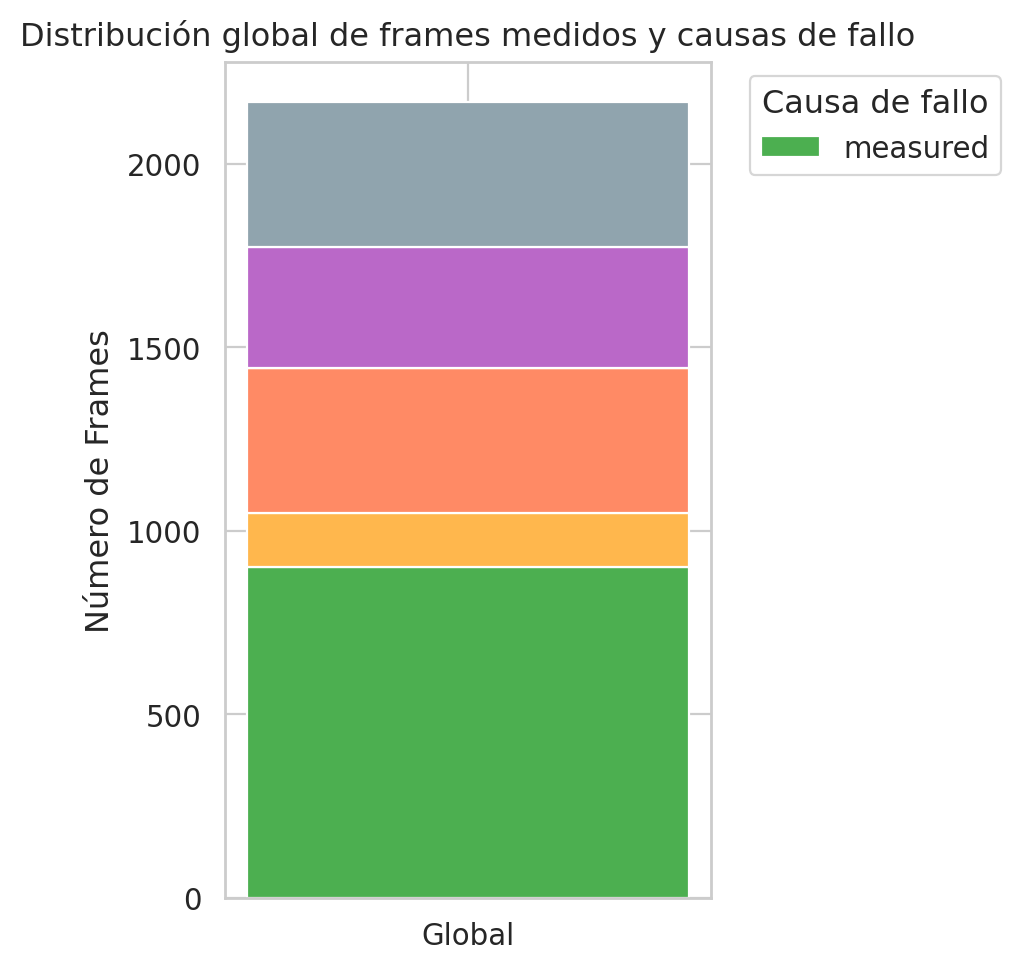

failure_reason,measured,incomplete_3D,borders,overlap,aspect_ratio_fail,other
source_folder,,,,,,
10_44_11-0,7,74,83,0,1,3
10_48_44-0,83,11,23,0,2,10
10_48_44-1,96,0,8,0,12,76
10_54_07-0,63,7,81,0,15,36
10_58_20-0,115,1,45,0,49,49
11_00_27-0,90,26,18,0,9,27
11_08_39-0,127,20,30,0,12,93
11_10_50-0,160,0,76,0,32,93
11_37_10-0,161,7,31,0,198,10


In [ ]:


df_raw_agg['unique_track'] = df_raw_agg['source_folder'].astype(str) + "_" + df_raw_agg['track_id'].astype(str)
df_raw_agg["failure_reason"] = df_raw_agg.apply(
    lambda row: rutils.classify_failure(row, ASPECT_RATIO_THR=ASPECT_RATIO_THR),
    axis=1
)


rutils.plot_frame_failures(df_raw_agg, figsize_video=(12,6), figsize_global=(5,5), show_global=True)

rutils.plot_tracks_failure_distribution(df_raw_agg, aspect_ratio_thr=3.0, show_global=True, figsize_video=(12,6), figsize_global=(5,5))
rutils.plot_aspect_ratio_vs_length(df_raw_agg, ASPECT_RATIO_THR=ASPECT_RATIO_THR, figsize=(10, 8))

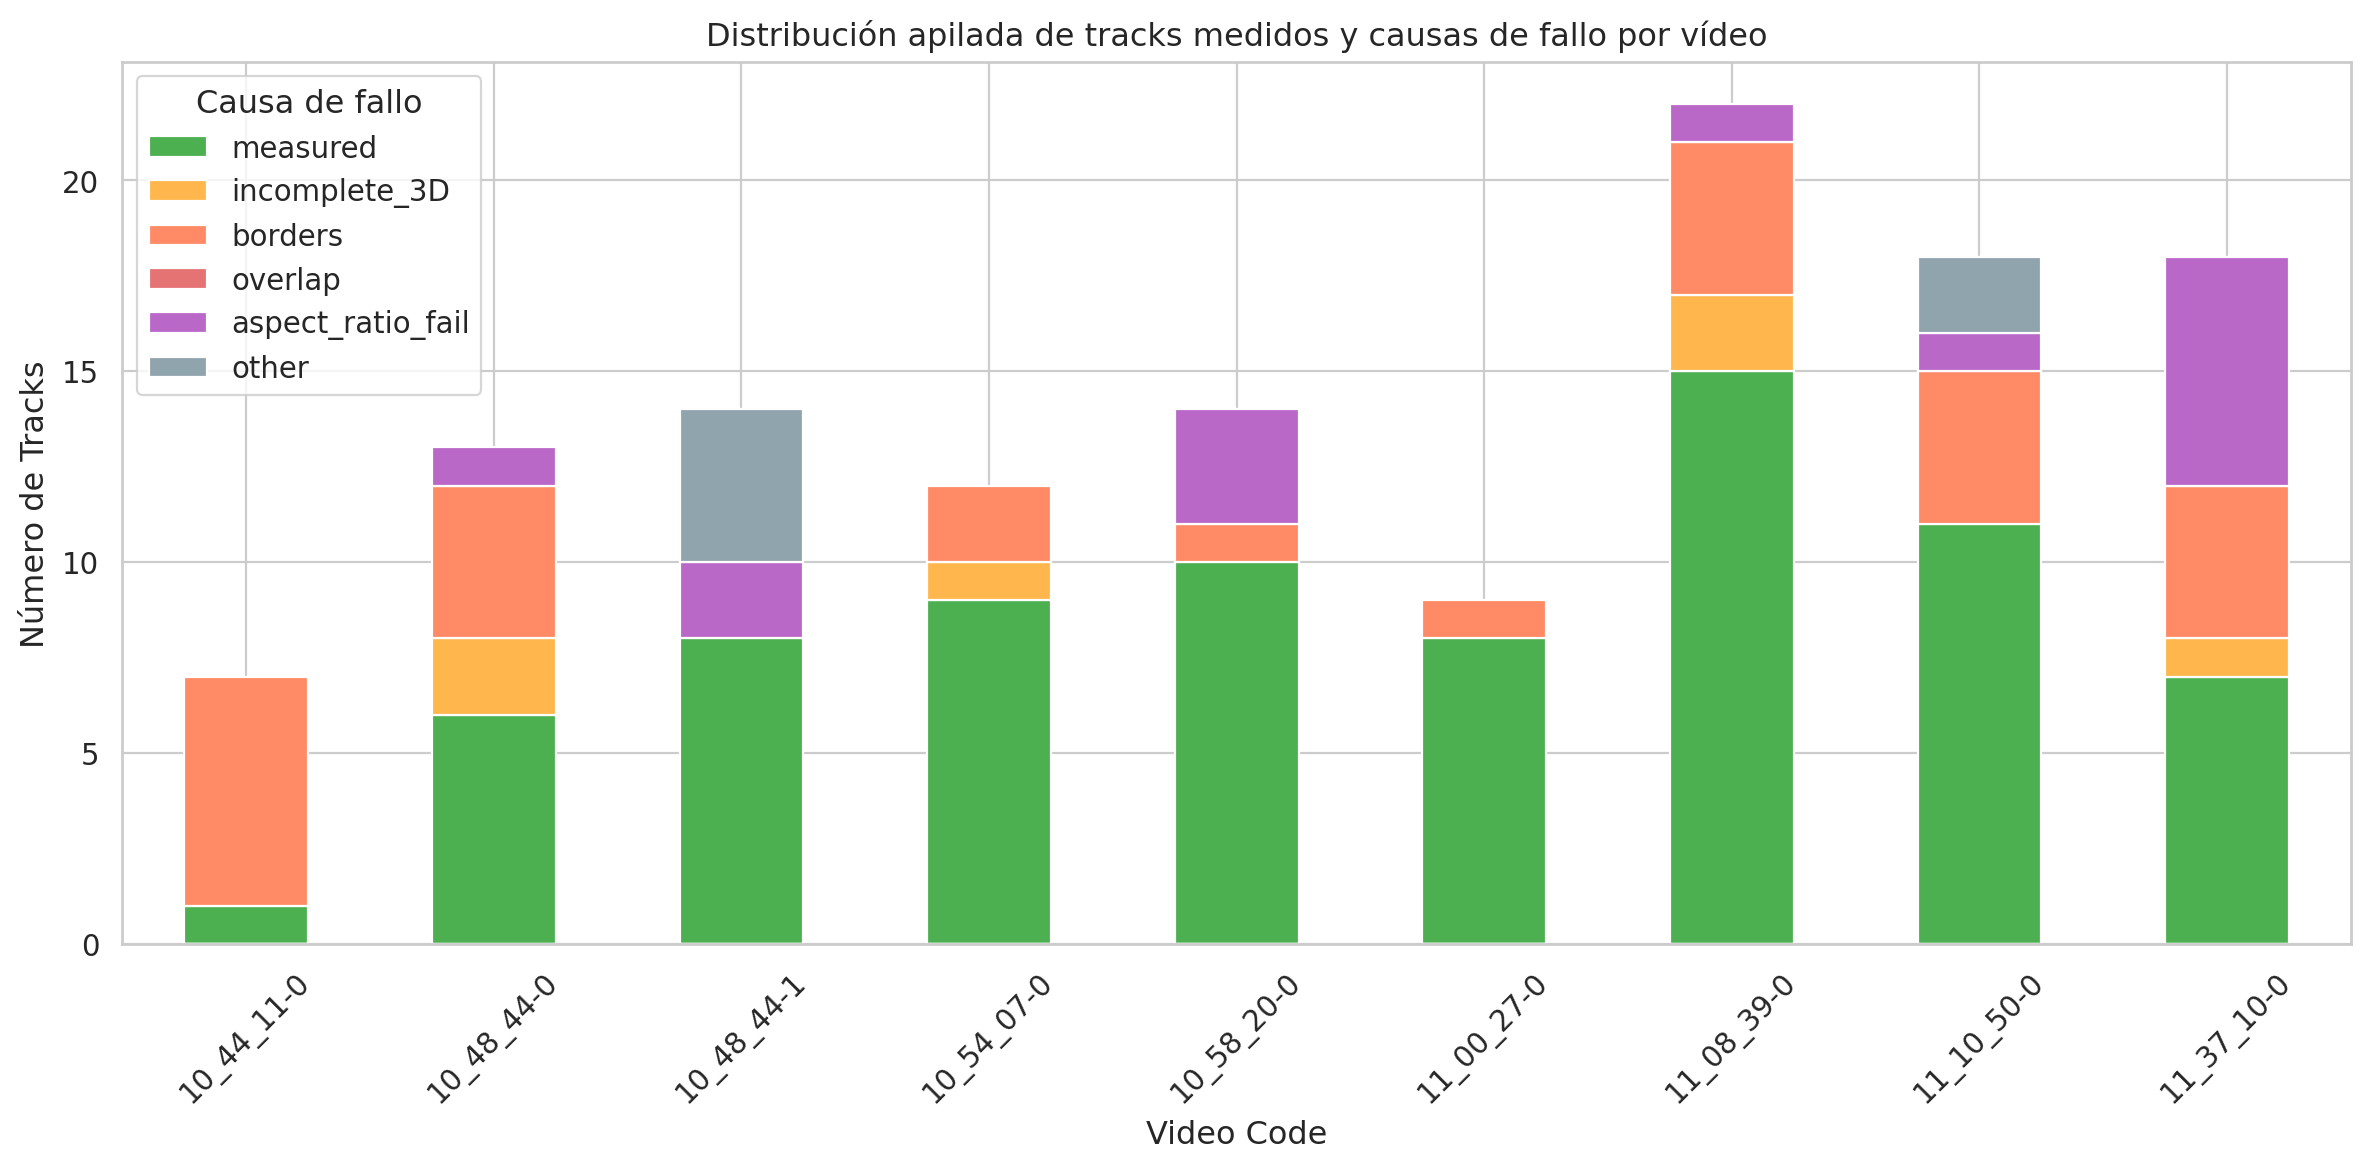

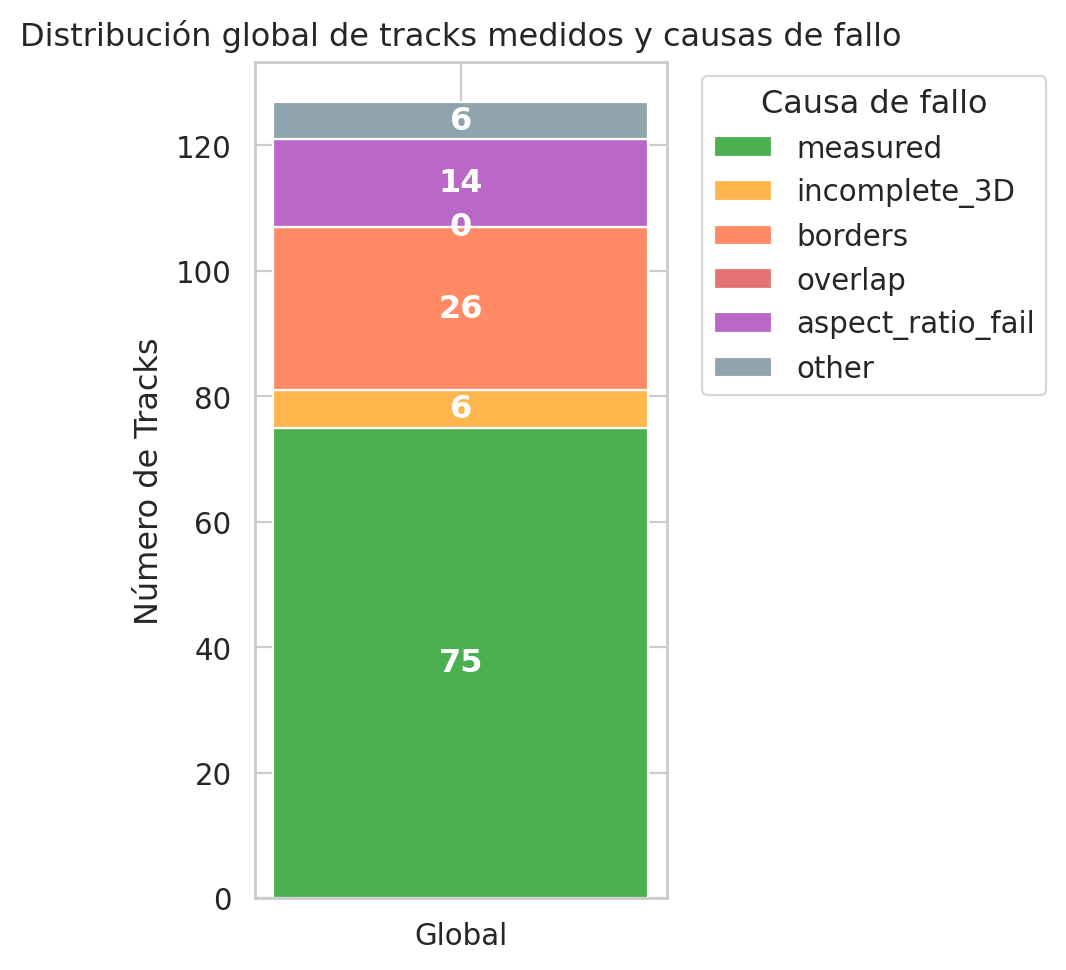

,unique_track,track_failure_reason,source_folder
0,10_44_11-0_-1,borders,10_44_11-0
1,10_44_11-0_13,borders,10_44_11-0
2,10_44_11-0_15,borders,10_44_11-0
3,10_44_11-0_3,measured,10_44_11-0
4,10_44_11-0_7,borders,10_44_11-0
...,...,...,...
122,11_37_10-0_4,aspect_ratio_fail,11_37_10-0
123,11_37_10-0_41,aspect_ratio_fail,11_37_10-0
124,11_37_10-0_44,measured,11_37_10-0
125,11_37_10-0_45,measured,11_37_10-0


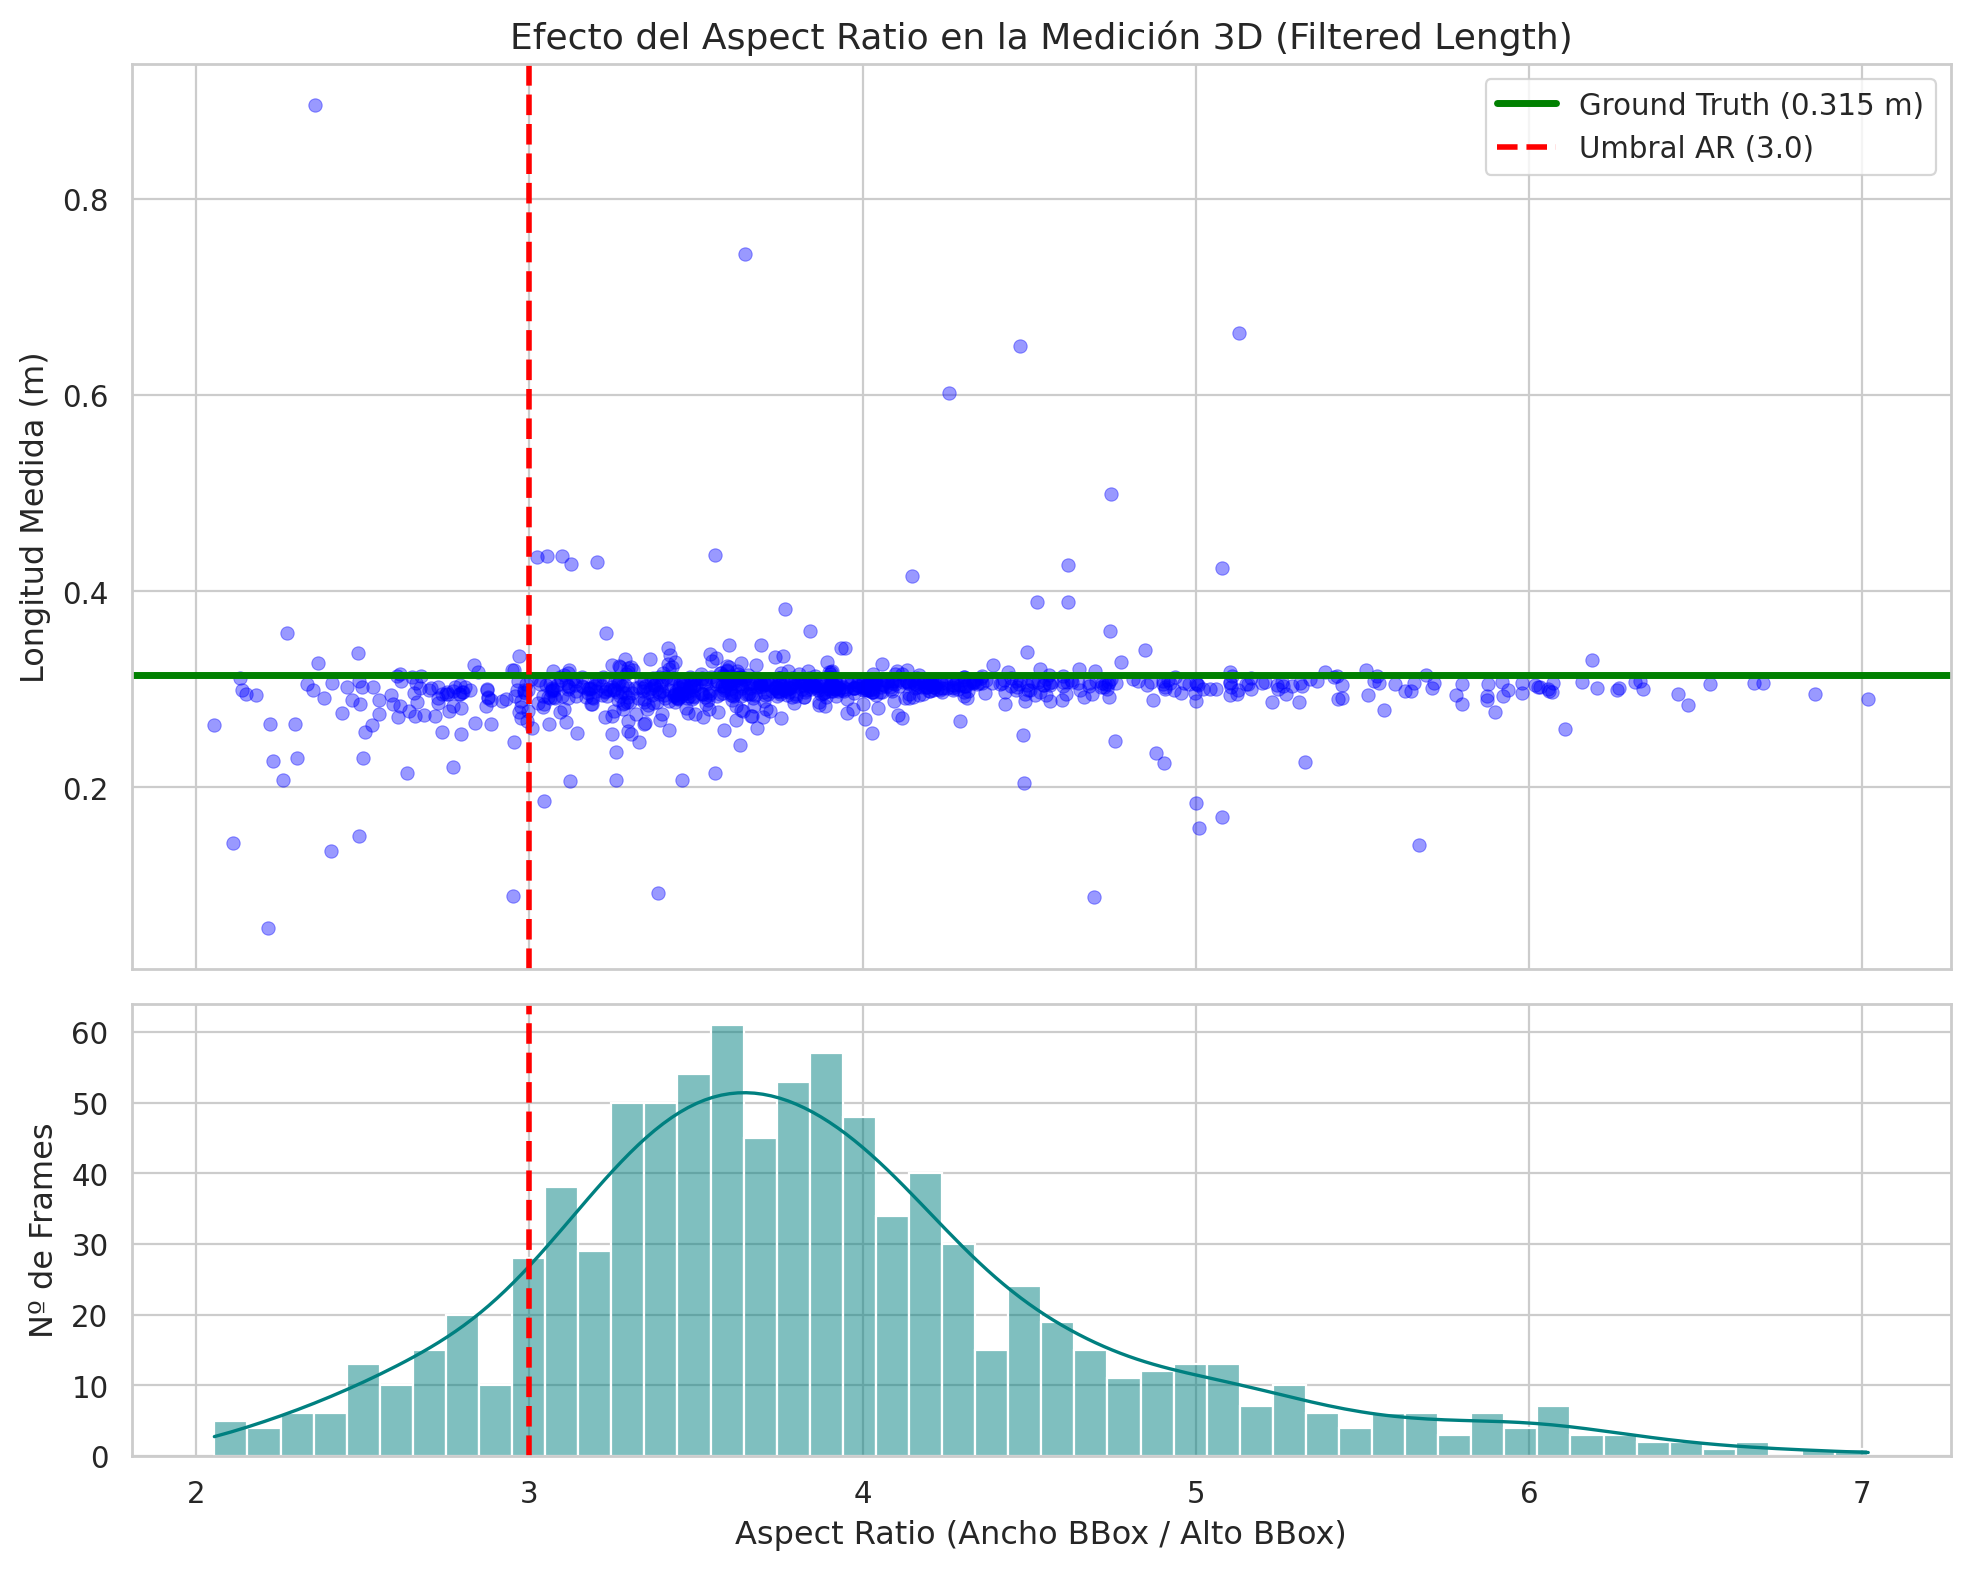

DF NAME IS df_raw_agg_2024_11_12
ETAPA DEL PIPELINE (CASCADA)                  | ERROR MEDIO     | FRAMES VIVOS    | PECES (TRACKS)
----------------------------------------------------------------------------------------------------
0. Base (HDBSCAN sin filtros)                 |  1.62 ± 2.78 cm |     902 frames |    45 tracks
1. + Filtro: Sin Bordes                       |  1.62 ± 2.78 cm |     902 frames |    45 tracks
2. + Filtro: Sin Solapamiento                 |  1.62 ± 2.78 cm |     902 frames |    45 tracks
3. + Filtro: Aspect Ratio >= 3.0              |  1.19 ± 1.91 cm |     795 frames |    40 tracks
4. + Filtro: Ángulo Z <= 20.0º                |  1.28 ± 2.97 cm |     409 frames |    26 tracks
5. + Filtro: is_3D_complete                   |  1.28 ± 2.97 cm |     409 frames |    26 tracks


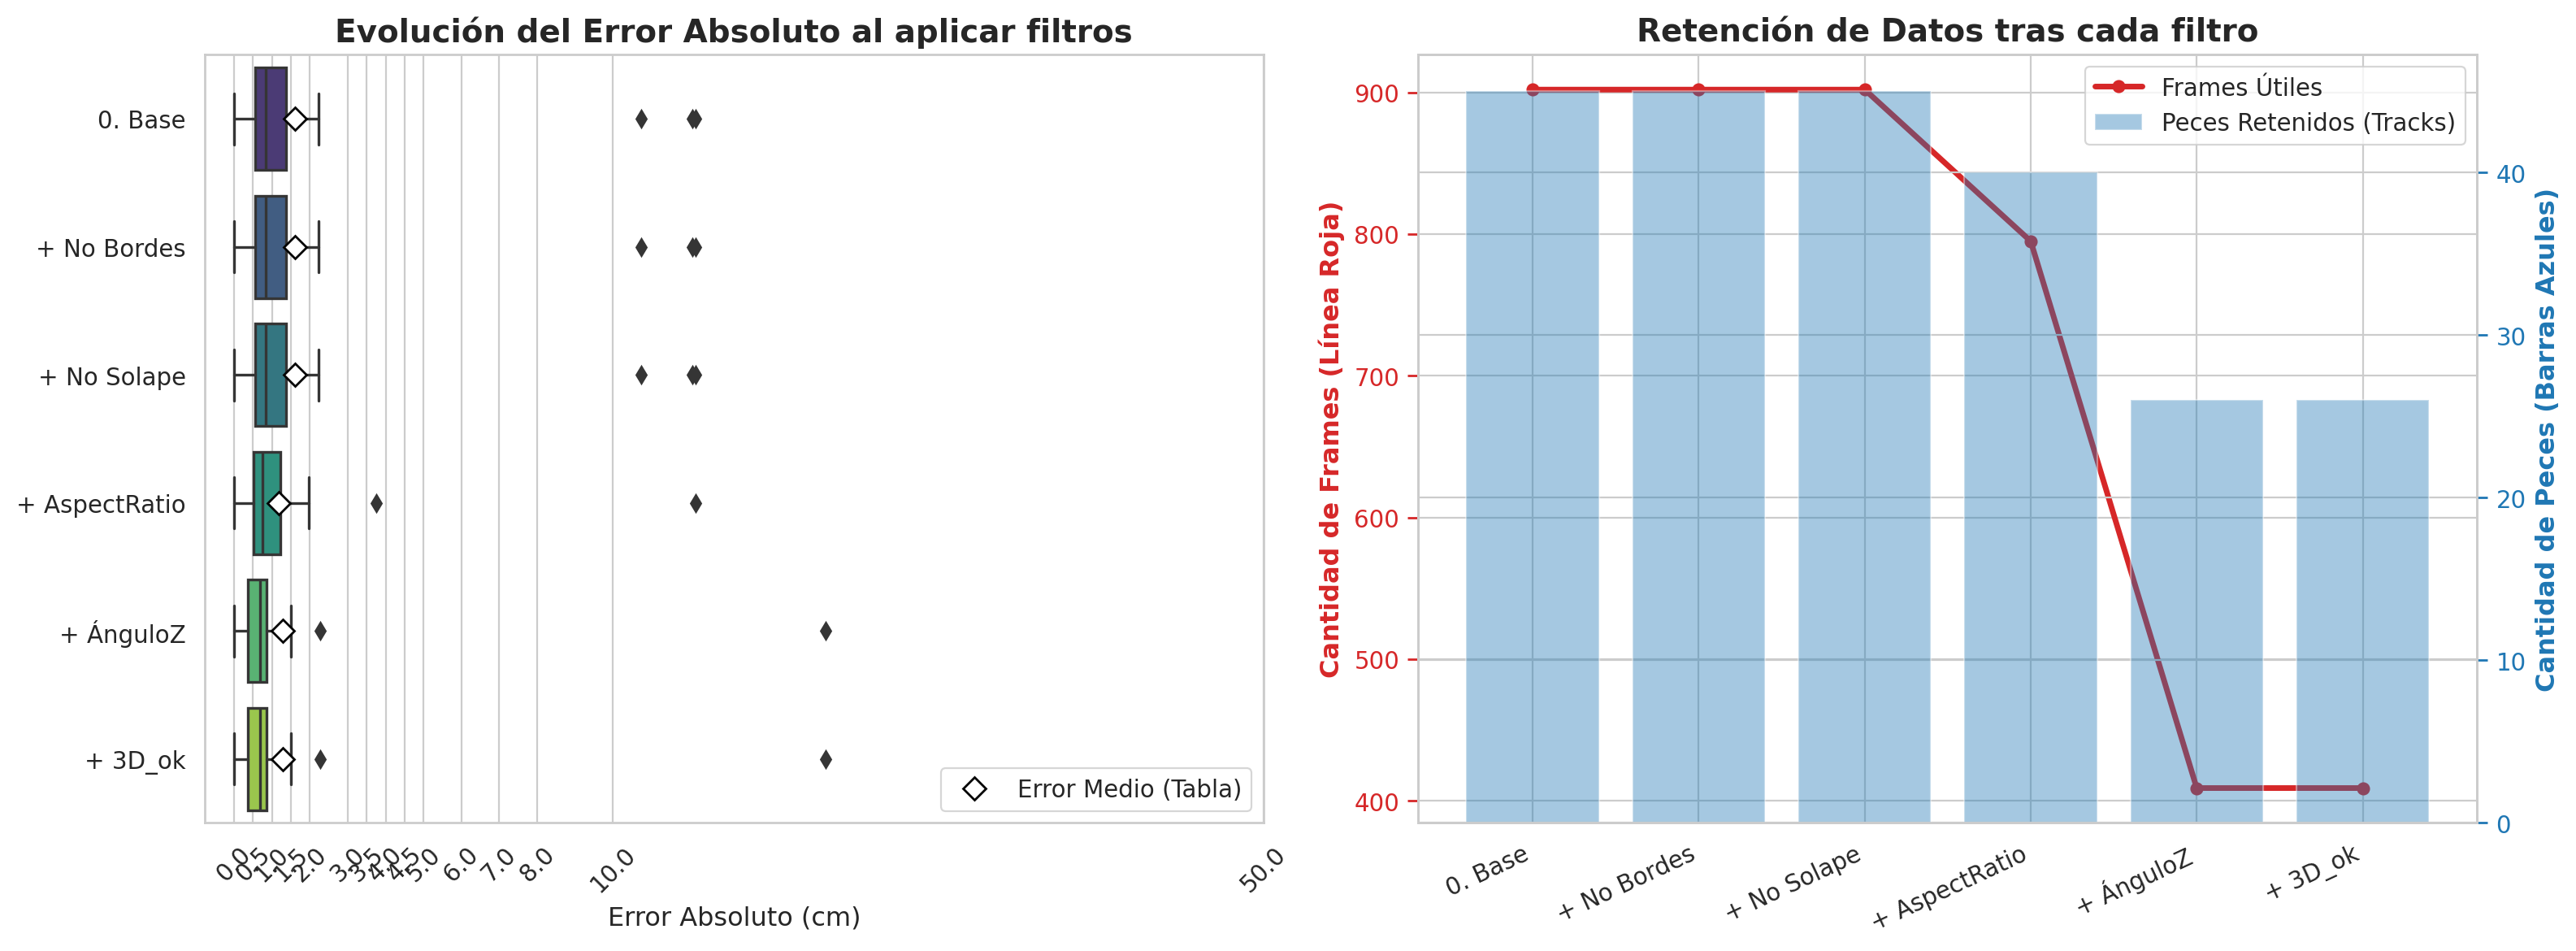

DF NAME IS df_raw_agg_2024_11_28
ETAPA DEL PIPELINE (CASCADA)                  | ERROR MEDIO     | FRAMES VIVOS    | PECES (TRACKS)
----------------------------------------------------------------------------------------------------
0. Base (HDBSCAN sin filtros)                 |  3.70 ± 7.49 cm |    3216 frames |    62 tracks
1. + Filtro: Sin Bordes                       |  2.20 ± 4.46 cm |    2996 frames |    54 tracks
2. + Filtro: Sin Solapamiento                 |  2.20 ± 4.46 cm |    2996 frames |    54 tracks
3. + Filtro: Aspect Ratio >= 3.0              |  1.57 ± 3.10 cm |    2876 frames |    52 tracks
4. + Filtro: Ángulo Z <= 20.0º                |  0.67 ± 1.00 cm |    2098 frames |    38 tracks
5. + Filtro: is_3D_complete                   |  0.67 ± 1.00 cm |    2096 frames |    38 tracks


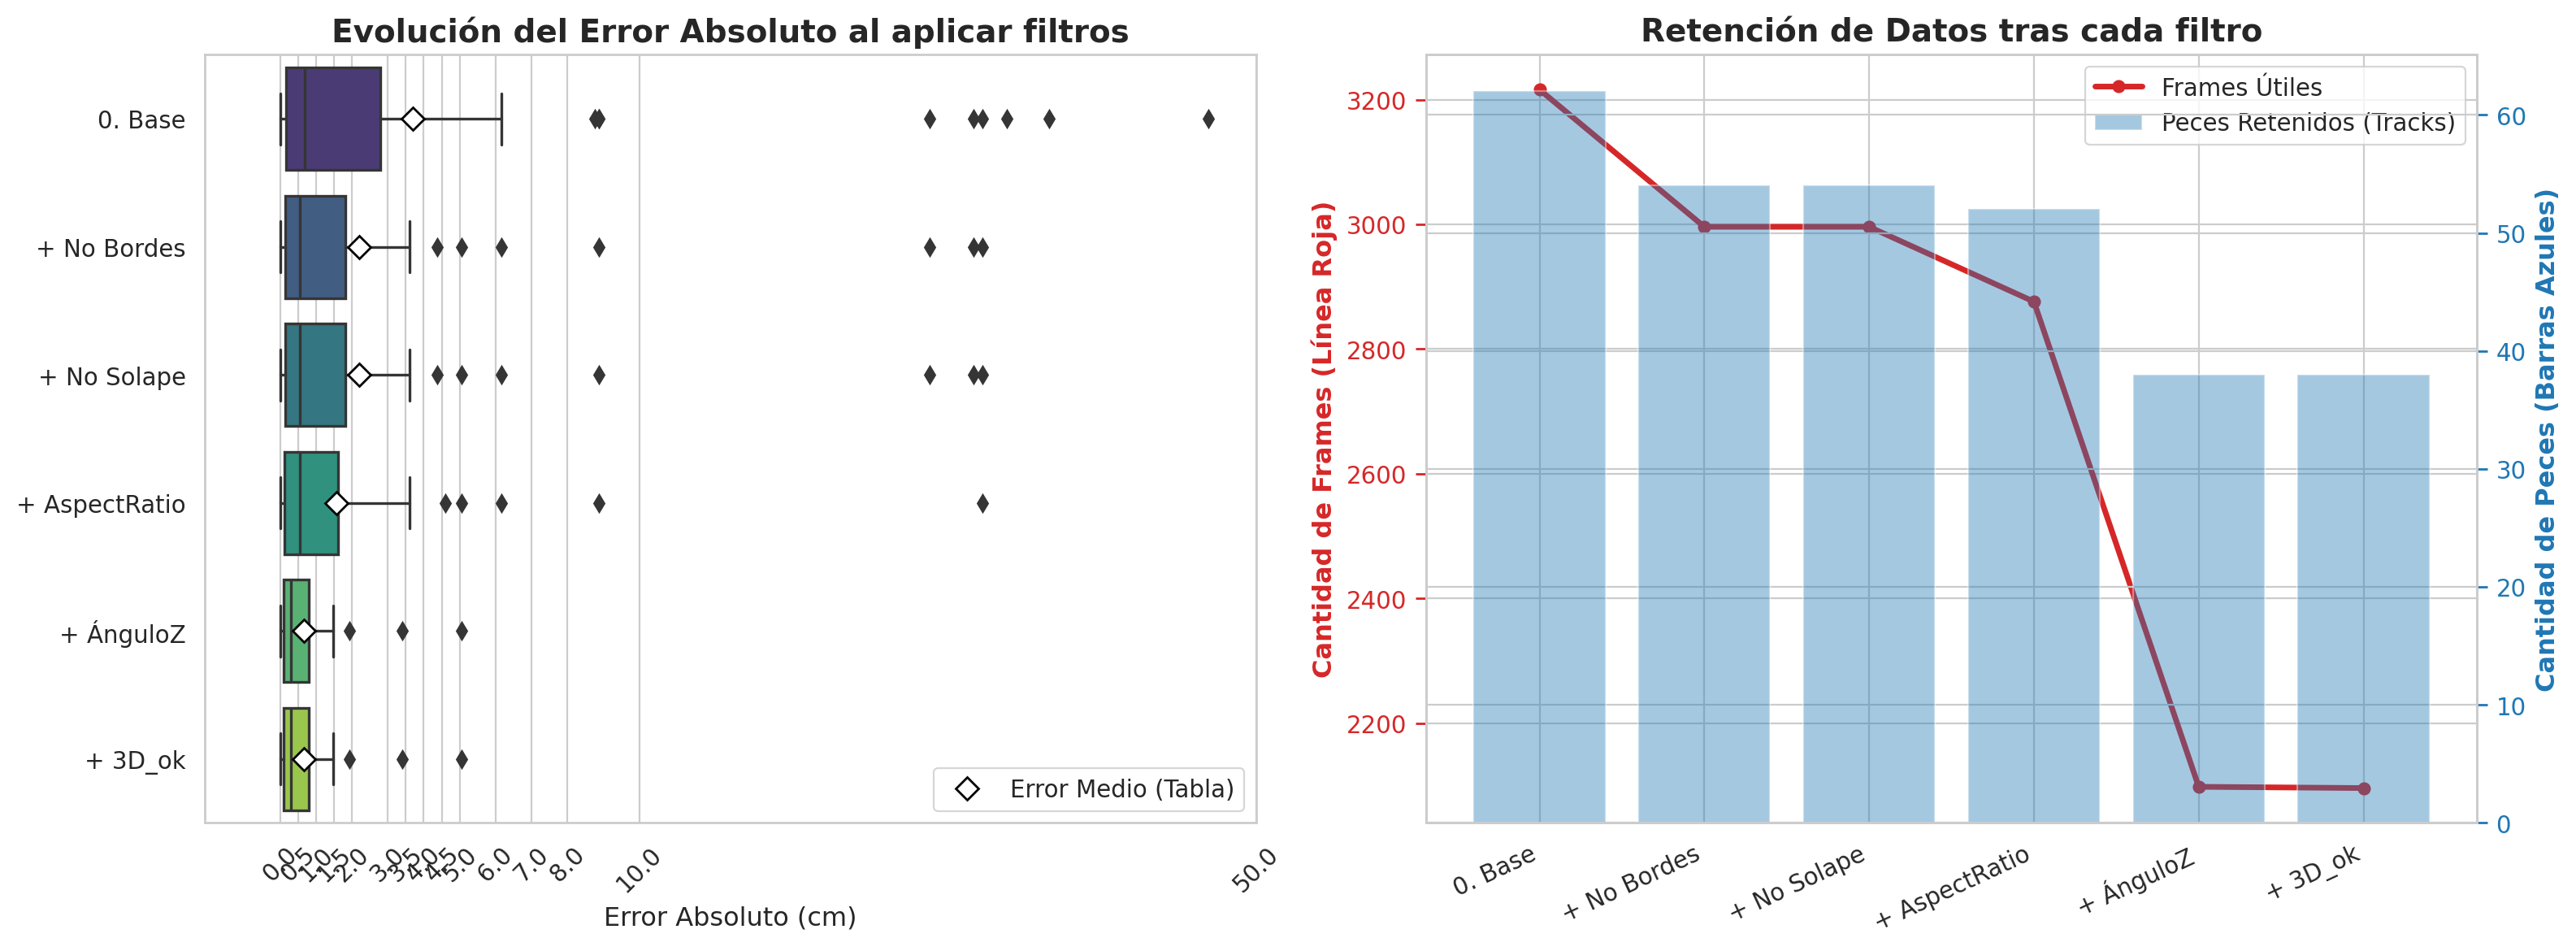

DF NAME IS df_raw_agg_2025_05_08
ETAPA DEL PIPELINE (CASCADA)                  | ERROR MEDIO     | FRAMES VIVOS    | PECES (TRACKS)
----------------------------------------------------------------------------------------------------
0. Base (HDBSCAN sin filtros)                 |  3.34 ± 2.06 cm |     134 frames |     5 tracks
1. + Filtro: Sin Bordes                       |  3.34 ± 2.06 cm |     134 frames |     5 tracks
2. + Filtro: Sin Solapamiento                 |  3.34 ± 2.06 cm |     134 frames |     5 tracks
3. + Filtro: Aspect Ratio >= 3.0              |  3.42 ± 1.97 cm |     116 frames |     5 tracks
4. + Filtro: Ángulo Z <= 20.0º                |  2.18 ± 0.51 cm |      87 frames |     3 tracks
5. + Filtro: is_3D_complete                   |  2.18 ± 0.51 cm |      87 frames |     3 tracks


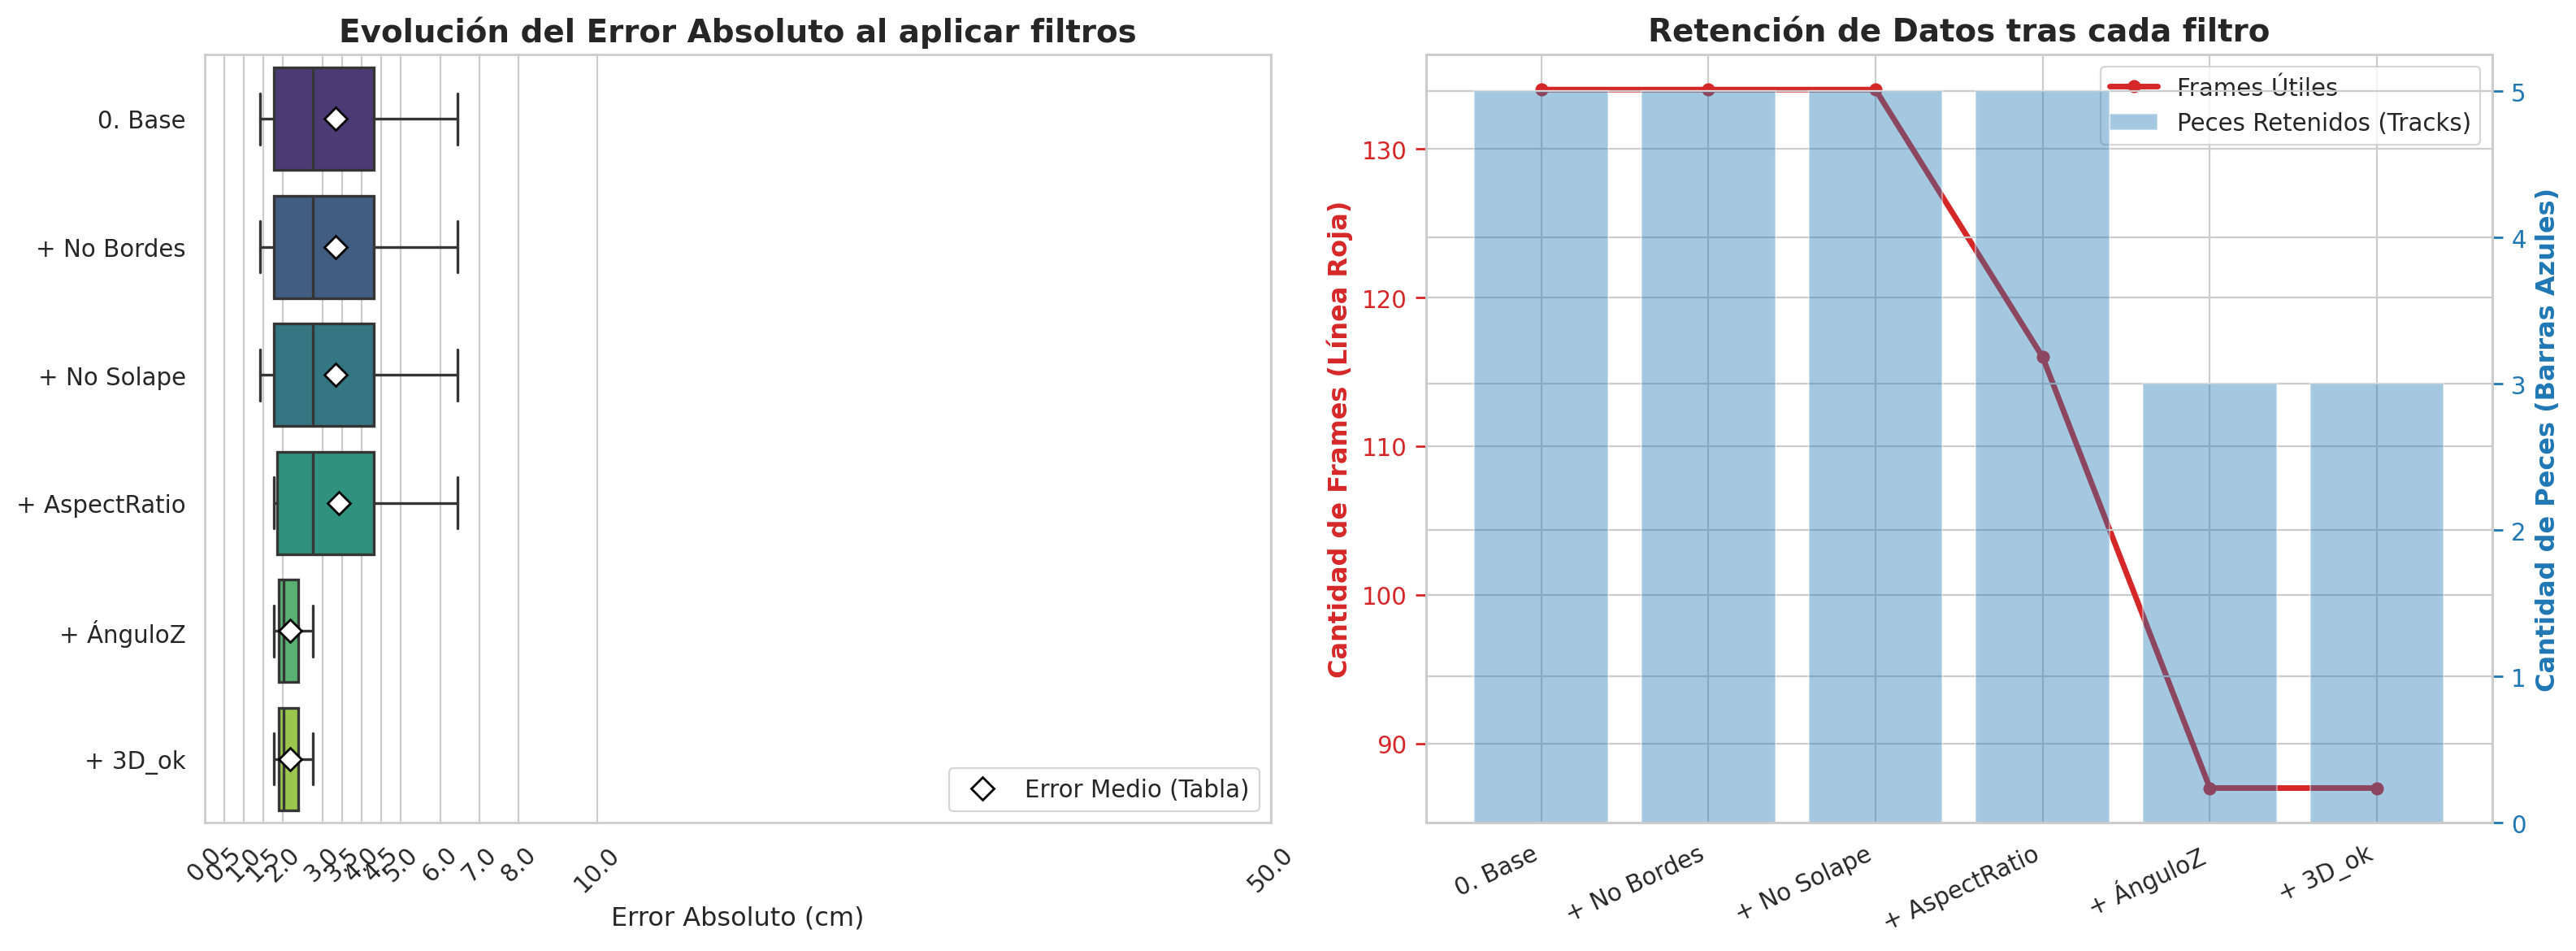

DF NAME IS df_raw_agg_2025_08_21
ETAPA DEL PIPELINE (CASCADA)                  | ERROR MEDIO     | FRAMES VIVOS    | PECES (TRACKS)
----------------------------------------------------------------------------------------------------
0. Base (HDBSCAN sin filtros)                 |  4.13 ± 3.73 cm |   14295 frames |    50 tracks
1. + Filtro: Sin Bordes                       |  4.13 ± 3.73 cm |   14295 frames |    50 tracks
2. + Filtro: Sin Solapamiento                 |  4.14 ± 3.75 cm |   14278 frames |    50 tracks
3. + Filtro: Aspect Ratio >= 3.0              |  2.98 ± 3.34 cm |    5941 frames |    32 tracks
4. + Filtro: Ángulo Z <= 20.0º                |  1.24 ± 1.77 cm |    1109 frames |    25 tracks
5. + Filtro: is_3D_complete                   | --- VACÍO ---


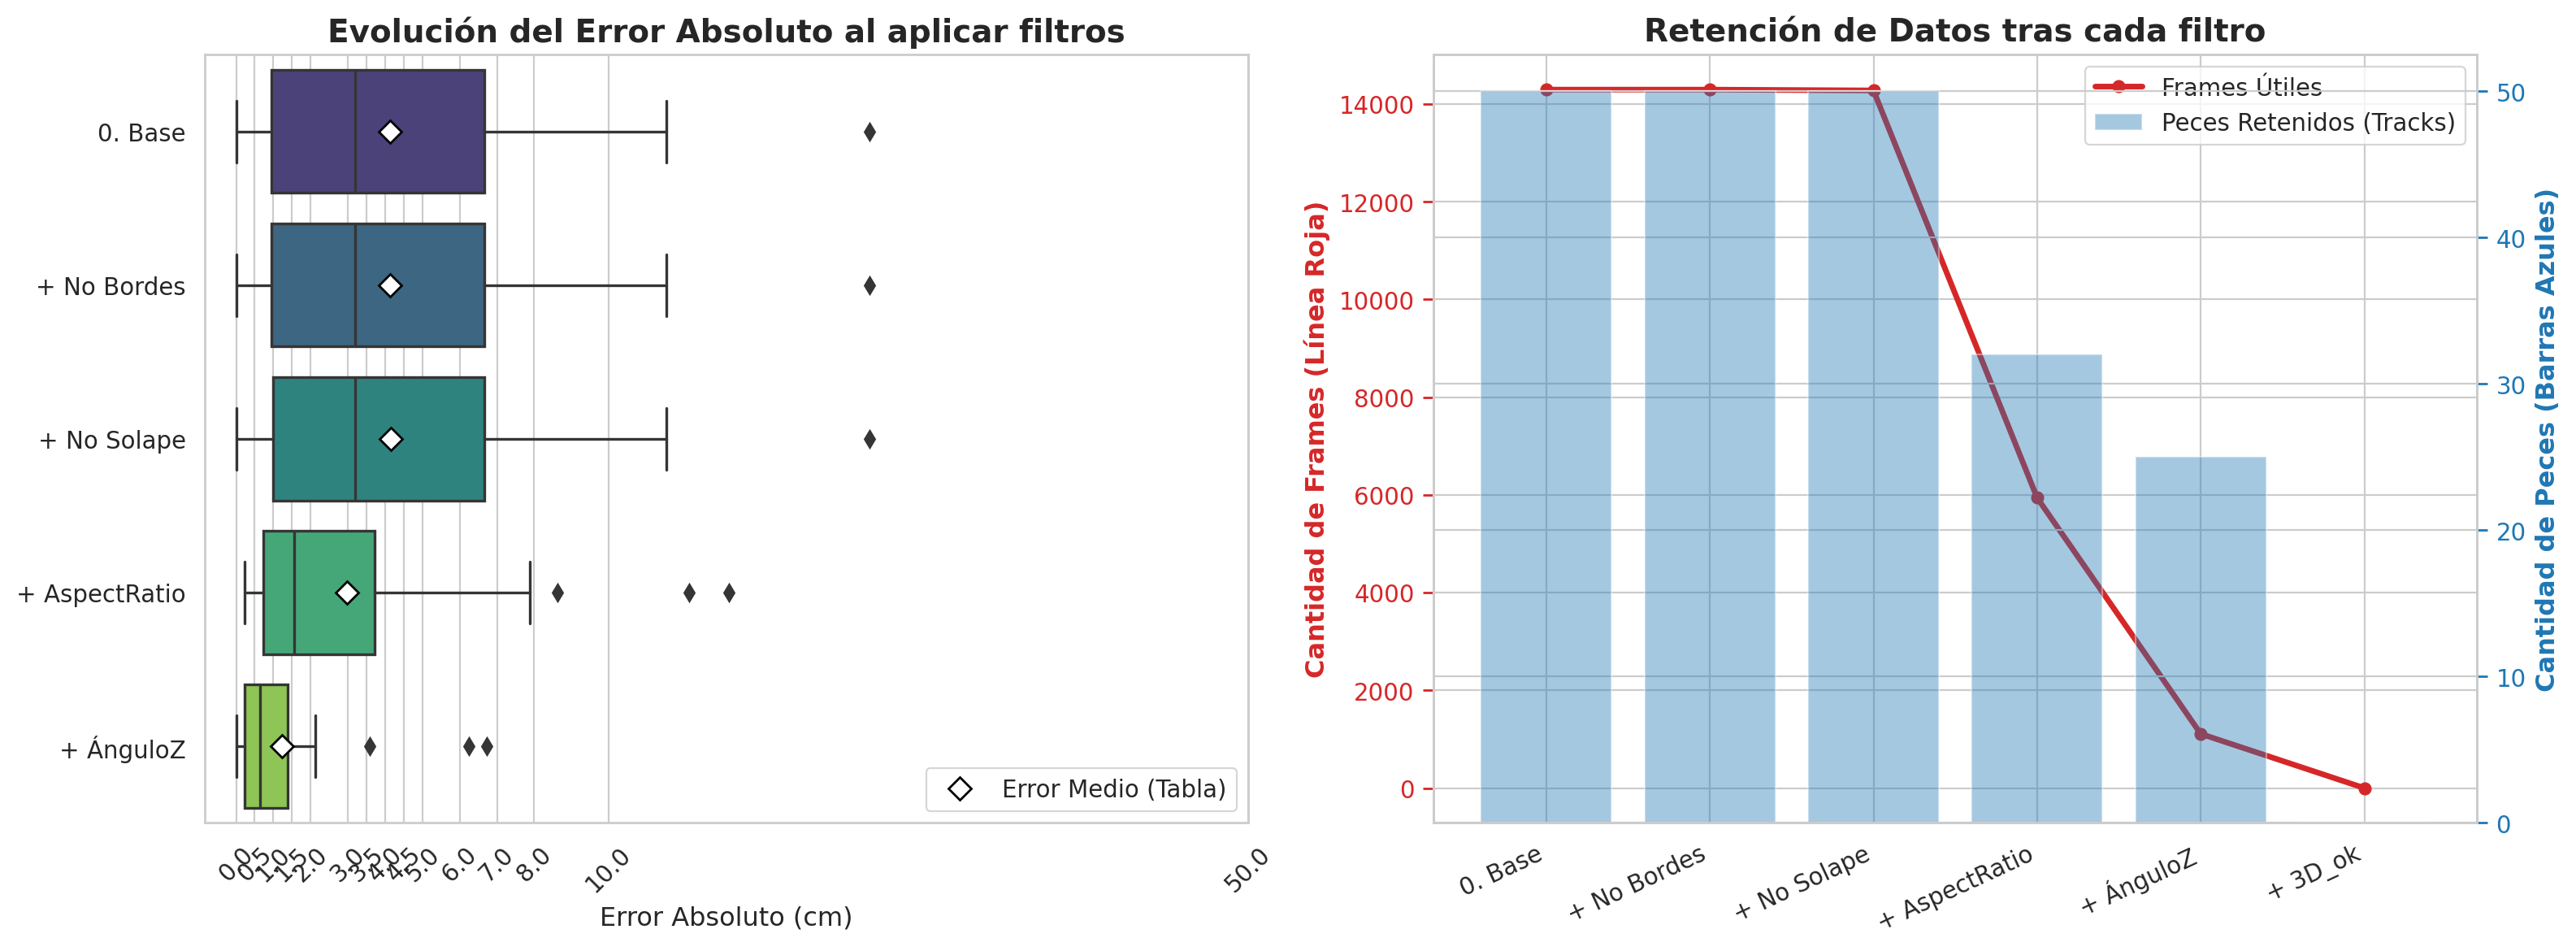

DF NAME IS df_raw_agg_pool
ETAPA DEL PIPELINE (CASCADA)                  | ERROR MEDIO     | FRAMES VIVOS    | PECES (TRACKS)
----------------------------------------------------------------------------------------------------
0. Base (HDBSCAN sin filtros)                 |  2.85 ± 5.92 cm |    4252 frames |   112 tracks
1. + Filtro: Sin Bordes                       |  2.00 ± 3.72 cm |    4032 frames |   104 tracks
2. + Filtro: Sin Solapamiento                 |  2.00 ± 3.72 cm |    4032 frames |   104 tracks
3. + Filtro: Aspect Ratio >= 3.0              |  1.51 ± 2.64 cm |    3787 frames |    97 tracks
4. + Filtro: Ángulo Z <= 20.0º                |  0.97 ± 2.01 cm |    2594 frames |    67 tracks
5. + Filtro: is_3D_complete                   |  0.97 ± 2.01 cm |    2592 frames |    67 tracks


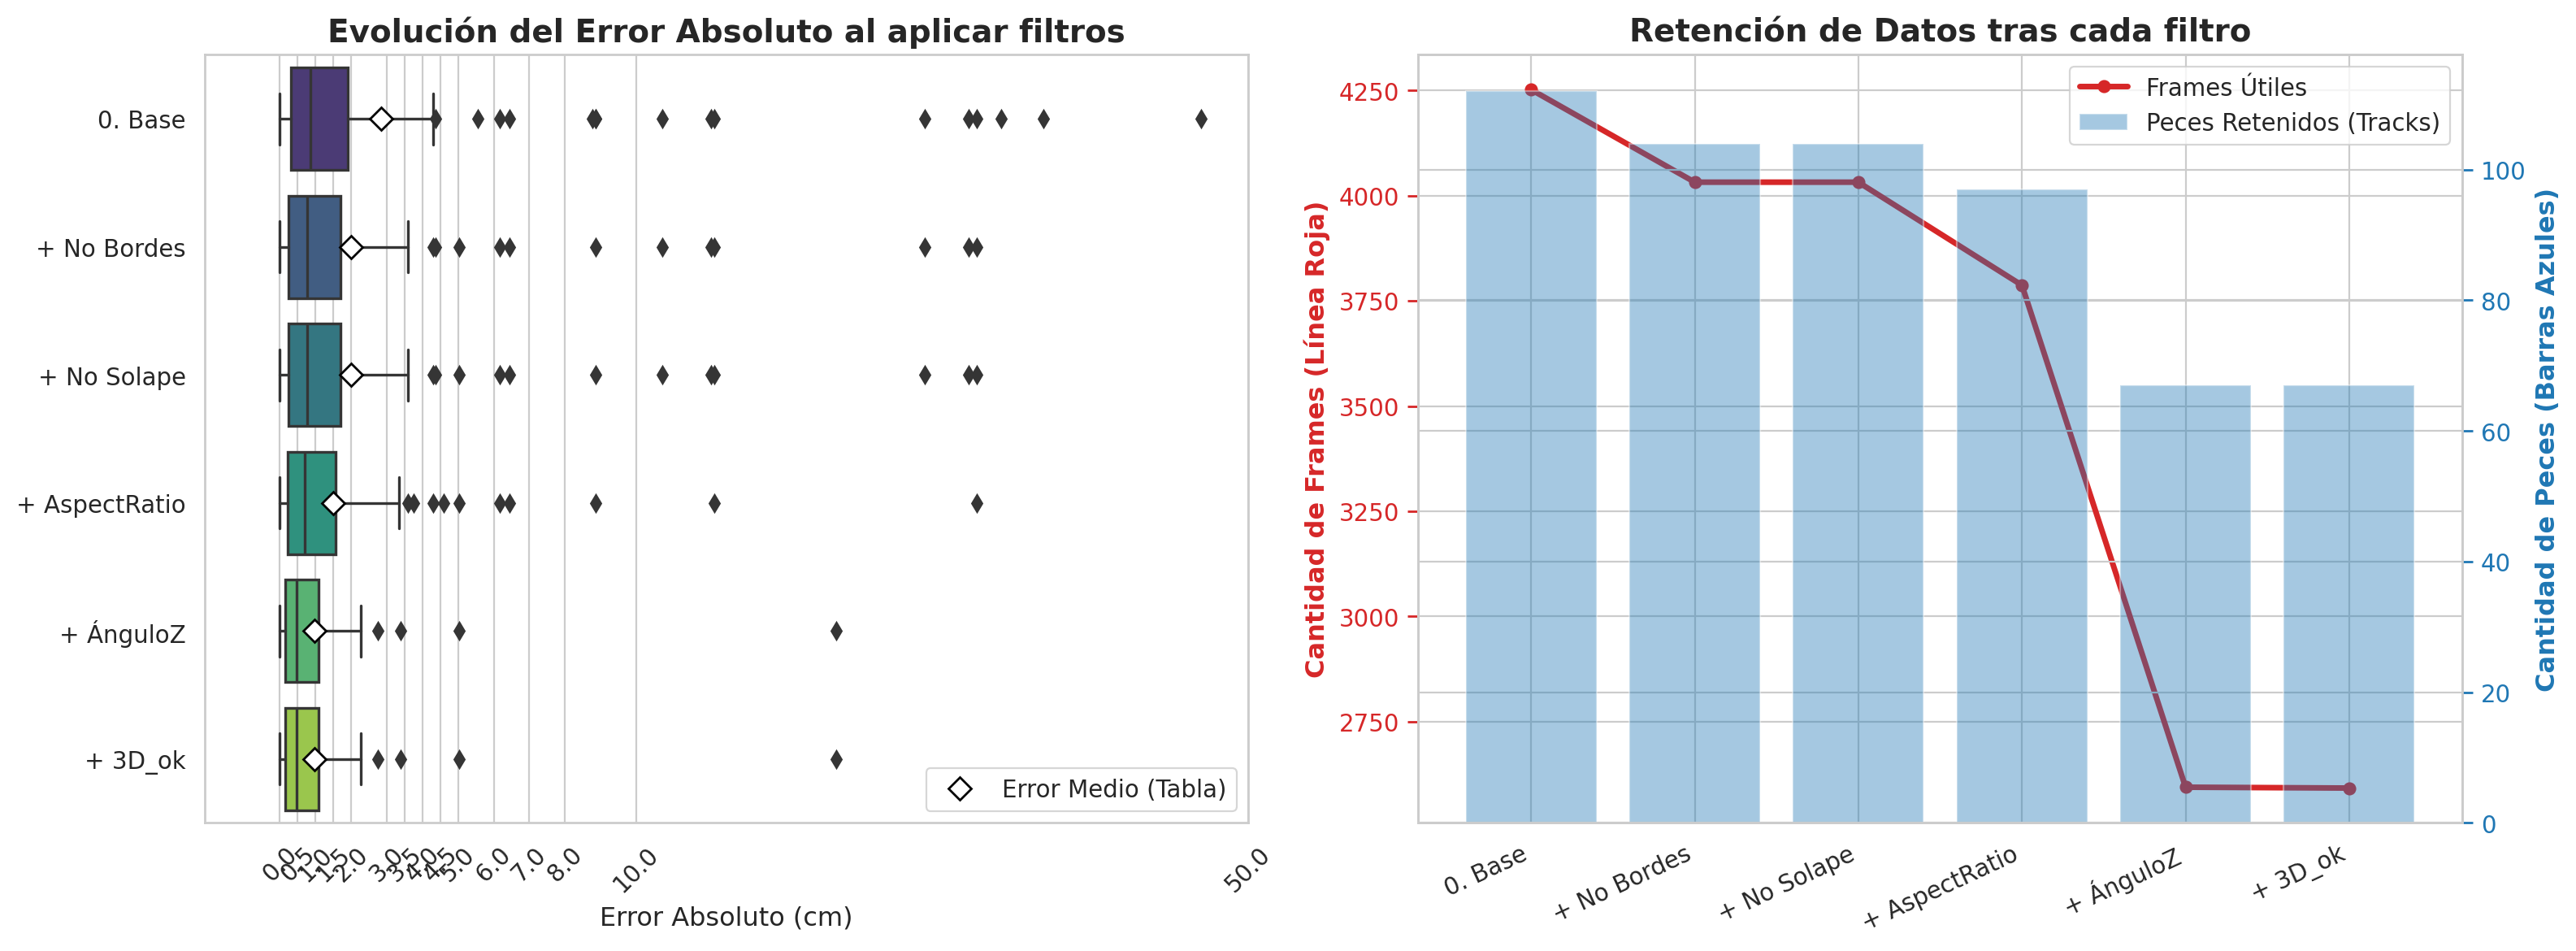

{'0. Base (HDBSCAN sin filtros)':        video_day source_folder   frame_id  class_name  object_id  track_id  \
66    2024_11_12    10_44_11_0  frame_108           0        255         3   
70    2024_11_12    10_44_11_0  frame_115           0        255         3   
72    2024_11_12    10_44_11_0  frame_118           0        255         3   
77    2024_11_12    10_44_11_0  frame_126           0        255         3   
120   2024_11_12    10_44_11_0  frame_285           0        255         3   
...          ...           ...        ...         ...        ...       ...   
9563  2025_05_08    11_14_52_0  frame_623           0        255         1   
9564  2025_05_08    11_14_52_0  frame_625           0        255         1   
9565  2025_05_08    11_14_52_0  frame_626           0        255         1   
9566  2025_05_08    11_14_52_0  frame_627           0        255         1   
9567  2025_05_08    11_14_52_0  frame_628           0        255         1   

      is_3D_complete  in_imag

In [6]:
df_names = [
    "df_raw_agg_2024_11_12",
    "df_raw_agg_2024_11_28",
    "df_raw_agg_2025_05_08",
    "df_raw_agg_2025_08_21",
    "df_raw_agg_pool"
]

df_results={}
for df_name in df_names:
    df_raw = globals()[df_name]  # <-- toma el DataFrame real
    cprint(f"DF NAME IS {df_name}","cyan")
    stages_dict, agg_stages_dict = rutils.plot_ablation_pipeline(
        df_raw, ASPECT_RATIO_THR=ASPECT_RATIO_THR, ANGLE_THR=ANGLE_THR   
    )
    df_results[df_name] = agg_stages_dict
    
print(stages_dict)

In [37]:


# List to store the summary statistics for each day
summary_stats = []

# Iterate over the results dictionary you just created
for df_name, agg_stages_dict in df_results.items():
    
    # 1. Dynamically get the key of the LAST filtering stage
    # (This ensures it won't break if you change the filter name in the future)
    last_stage_key = list(agg_stages_dict.keys())[-1]
    df_final = agg_stages_dict[last_stage_key]
    
    # If the dataframe is empty after applying all filters, warn and skip
    if df_final.empty:
        print(f"⚠️ {df_name}: No fish survived all the filters.")
        last_stage_key = list(agg_stages_dict.keys())[-2]
        df_final = agg_stages_dict[last_stage_key]
        # continue
        
    # =========================================================
    # 2. SAVE THE CSV FOR THE DAY (OR THE POOL)
    # =========================================================
    # Clean up the name so the file looks nice (e.g., 2024_11_12_final_filtered.csv)
    filename = f"{df_name.replace('df_raw_agg_', '')}_final_filtered.csv"
    
    df_final.to_csv(filename, index=False)
    print(f"💾 Saved CSV with clean tracks: {filename}")
    
    # =========================================================
    # 3. CALCULATE METRICS: MEAN, MEDIAN, AND STANDARD DEVIATION
    # =========================================================
    mean_err = df_final['abs_error_cm'].mean()
    median_err = df_final['abs_error_cm'].median()
    std_err = df_final['abs_error_cm'].std()
    
    total_fish = len(df_final)
    
    # Save the summary for this day in our list
    summary_stats.append({
        "dataset": df_name.replace('df_raw_agg_', ''),
        "total_valid_tracks": total_fish,
        "mean_abs_error_cm": round(mean_err, 2),
        "median_abs_error_cm": round(median_err, 2),
        "std_abs_error_cm": round(std_err, 2)
    })

# =========================================================
# 4. SAVE THE SUMMARY OF ALL METRICS
# =========================================================
if summary_stats:
    df_summary = pd.DataFrame(summary_stats)
    
    # Save the summary table
    df_summary.to_csv("daily_statistics_summary.csv", index=False)
    print("\n📊 Statistics summary saved in 'daily_statistics_summary.csv':")
    
    # Display it on the screen so you can see it instantly
    display(df_summary)

💾 Saved CSV with clean tracks: 2024_11_12_final_filtered.csv
💾 Saved CSV with clean tracks: 2024_11_28_final_filtered.csv
💾 Saved CSV with clean tracks: 2025_05_08_final_filtered.csv
⚠️ df_raw_agg_2025_08_21: No fish survived all the filters.
💾 Saved CSV with clean tracks: 2025_08_21_final_filtered.csv
💾 Saved CSV with clean tracks: pool_final_filtered.csv

📊 Statistics summary saved in 'daily_statistics_summary.csv':


,dataset,total_valid_tracks,mean_abs_error_cm,median_abs_error_cm,std_abs_error_cm
0,2024_11_12,26,1.28,0.68,2.97
1,2024_11_28,38,0.67,0.30,1.00
2,2025_05_08,3,2.18,2.02,0.51
3,2025_08_21,25,1.24,0.65,1.77
4,pool,67,0.97,0.48,2.01


In [ ]:
df_results["df_raw_agg_2024_11_12"].keys()

dict_keys(['0. Base (HDBSCAN sin filtros)', '1. + Filtro: Sin Bordes', '2. + Filtro: Sin Solapamiento', '3. + Filtro: Aspect Ratio >= 3.0', '4. + Filtro: Ángulo Z <= 20.0º', '5. + Filtro: is_3D_complete'])

In [40]:
# df_base_noviembre = df_results["df_raw_agg_2024_11_12"]["5. + Filtro: is_3D_complete"]
df_base_noviembre = df_results["df_raw_agg_2025_05_08"]["5. + Filtro: is_3D_complete"]

display(df_base_noviembre.sort_values(by='abs_error_cm', ascending=False))

,video_day,source_folder,track_id,n_frames_validos,calculated_length_cm,gt_cm,abs_error_cm,mean_elevation_deg
1,2025_05_08,11_20_56_1,7,7.0,36.249052,33.5,2.749052,8.377704
0,2025_05_08,11_20_56_1,1,64.0,35.519265,33.5,2.019265,-4.960565
2,2025_05_08,11_20_56_2,1,15.0,31.724447,33.5,1.775553,13.068193


In [48]:
# df_base_noviembre = df_results["df_raw_agg_2024_11_12"]["5. + Filtro: is_3D_complete"]
df_base_noviembre = df_results["df_raw_agg_2025_08_21"]["4. + Filtro: Ángulo Z <= 20.0º"]


# display(df_base_noviembre.sort_values(by='abs_error_cm', ascending=False))
# Con los paréntesis mágicos añadidos:
# peces_filtrados = df_raw_agg_2025_05_08[(df_raw_agg_2025_05_08["source_folder"] == "11_20_56_1") & (df_raw_agg_2025_05_08["track_id"] == 1)]

display(df_base_noviembre.sort_values(by='abs_error_cm', ascending=False))

,video_day,source_folder,track_id,n_frames_validos,calculated_length_cm,gt_cm,abs_error_cm,mean_elevation_deg
12,2025_08_21,13_34_24_compressed,1,22.0,22.383810,29.1,6.716190,-12.395710
17,2025_08_21,13_40_21_compressed,1,28.0,22.862839,29.1,6.237161,-10.119373
8,2025_08_21,12_13_38_compressed,9,6.0,25.518651,29.1,3.581349,8.080891
6,2025_08_21,12_12_06_compressed,1,58.0,31.219274,29.1,2.119274,-5.034773
15,2025_08_21,13_37_28_compressed,3,39.0,30.811279,29.1,1.711279,-6.980517
24,2025_08_21,13_58_40_compressed,1,60.0,30.650179,29.1,1.550179,-4.382477
3,2025_08_21,12_09_03_compressed,1,80.0,30.493932,29.1,1.393932,0.879132
21,2025_08_21,13_55_37_compressed,1,9.0,28.031978,29.1,1.068022,-14.237562
5,2025_08_21,12_10_35_compressed,1,44.0,29.978700,29.1,0.878700,-1.185763
7,2025_08_21,12_13_38_compressed,1,27.0,29.802136,29.1,0.702136,0.989930


In [60]:
# df_base_noviembre = df_results["df_raw_agg_2024_11_12"]["5. + Filtro: is_3D_complete"]
df_base_noviembre = df_results["df_raw_agg_2025_08_21"]["4. + Filtro: Ángulo Z <= 20.0º"]
pd.set_option('display.max_rows', None)

mask_2 = df_raw_agg_2025_08_21['in_image_borders'] == False
mask_3 = mask_2 & (df_raw_agg_2025_08_21['does_overlap'] == False)
mask_4 = mask_3 & (df_raw_agg_2025_08_21['aspect_ratio'] >= ASPECT_RATIO_THR)
mask_5 = mask_4 & df_raw_agg_2025_08_21['elevation_deg'].notna() & (df_raw_agg_2025_08_21['elevation_deg'].abs() <= ANGLE_THR)


pd.set_option('display.max_columns', None)
# display(df_base_noviembre.sort_values(by='abs_error_cm', ascending=False))
# Con los paréntesis mágicos añadidos:
# peces_filtrados = df_raw_agg_2025_05_08[(df_raw_agg_2025_05_08["source_folder"] == "11_20_56_1") & (df_raw_agg_2025_05_08["track_id"] == 1)]

# display(df_base_noviembre.sort_values(by='abs_error_cm', ascending=False))
peces_filtrados = df_raw_agg_2025_08_21[mask_5]
# peces_filtrados = df_raw_agg_2025_08_21[(df_raw_agg_2025_08_21["source_folder"] == "13_34_24_compressed") & (df_raw_agg_2025_08_21["track_id"] == 1)& (df_raw_agg_2025_08_21["filtered_length"] > 0.0)]
peces_filtrados_2 = peces_filtrados[(peces_filtrados["source_folder"] == "13_34_24_compressed") & (peces_filtrados["track_id"] == 1)]
peces_filtrados_2

,video_day,source_folder,frame_id,class_name,object_id,track_id,is_3D_complete,in_image_borders,does_overlap,is_front_fish,aspect_ratio,fish_3d_ok,overlapping_fish_ids,fish_direction,elevation_deg,azimuth_deg,raw_length,filtered_length,spine_length,gt,abs_error_cm,rel_error_%,fish_dist_from_camera
13236,2025_08_21,13_34_24_compressed,frame_189,0,255,1,-1,False,False,True,3.081761,False,[],NaN,-1.000000,-1.000000,-1.0,-1.000000,0.163978,29.1,129.100000,NaN,1.880401
13237,2025_08_21,13_34_24_compressed,frame_190,0,255,1,-1,False,False,True,3.098385,False,[],NaN,-1.000000,-1.000000,-1.0,-1.000000,0.239603,29.1,129.100000,NaN,1.885322
13254,2025_08_21,13_34_24_compressed,frame_207,0,255,1,-1,False,False,True,3.375000,False,[],NaN,-2.740807,38.064424,-1.0,0.138771,0.155435,29.1,15.222909,51.982384,1.876011
13263,2025_08_21,13_34_24_compressed,frame_216,0,255,1,-1,False,False,True,3.308642,False,[],NaN,3.525308,32.337568,-1.0,0.159559,0.221264,29.1,13.144136,44.789396,1.873298
13271,2025_08_21,13_34_24_compressed,frame_224,0,255,1,-1,False,False,True,3.422484,False,[],NaN,-11.721629,28.570485,-1.0,0.205300,0.182580,29.1,8.570006,28.961958,1.863110
13316,2025_08_21,13_34_24_compressed,frame_269,0,255,1,-1,False,False,True,3.036642,False,[],NaN,-14.660906,28.090564,-1.0,0.210001,0.230033,29.1,8.099916,27.335350,1.866837
13356,2025_08_21,13_34_24_compressed,frame_309,0,255,1,-1,False,False,True,3.008439,False,[],NaN,-17.467793,51.502178,-1.0,0.184132,0.160769,29.1,10.686774,36.286415,1.874723
13379,2025_08_21,13_34_24_compressed,frame_332,0,255,1,-1,False,False,True,3.558824,False,[],NaN,-14.459370,36.408593,-1.0,0.210689,0.222620,29.1,8.031064,27.097108,1.868738
13404,2025_08_21,13_34_24_compressed,frame_357,0,255,1,-1,False,False,True,3.378831,False,[],NaN,-15.312136,31.786606,-1.0,0.223018,0.228640,29.1,6.798236,22.831266,1.875405
13406,2025_08_21,13_34_24_compressed,frame_359,0,255,1,-1,False,False,True,3.402062,False,[],NaN,-19.055829,37.525502,-1.0,0.219005,0.238370,29.1,7.199543,24.219870,1.865344


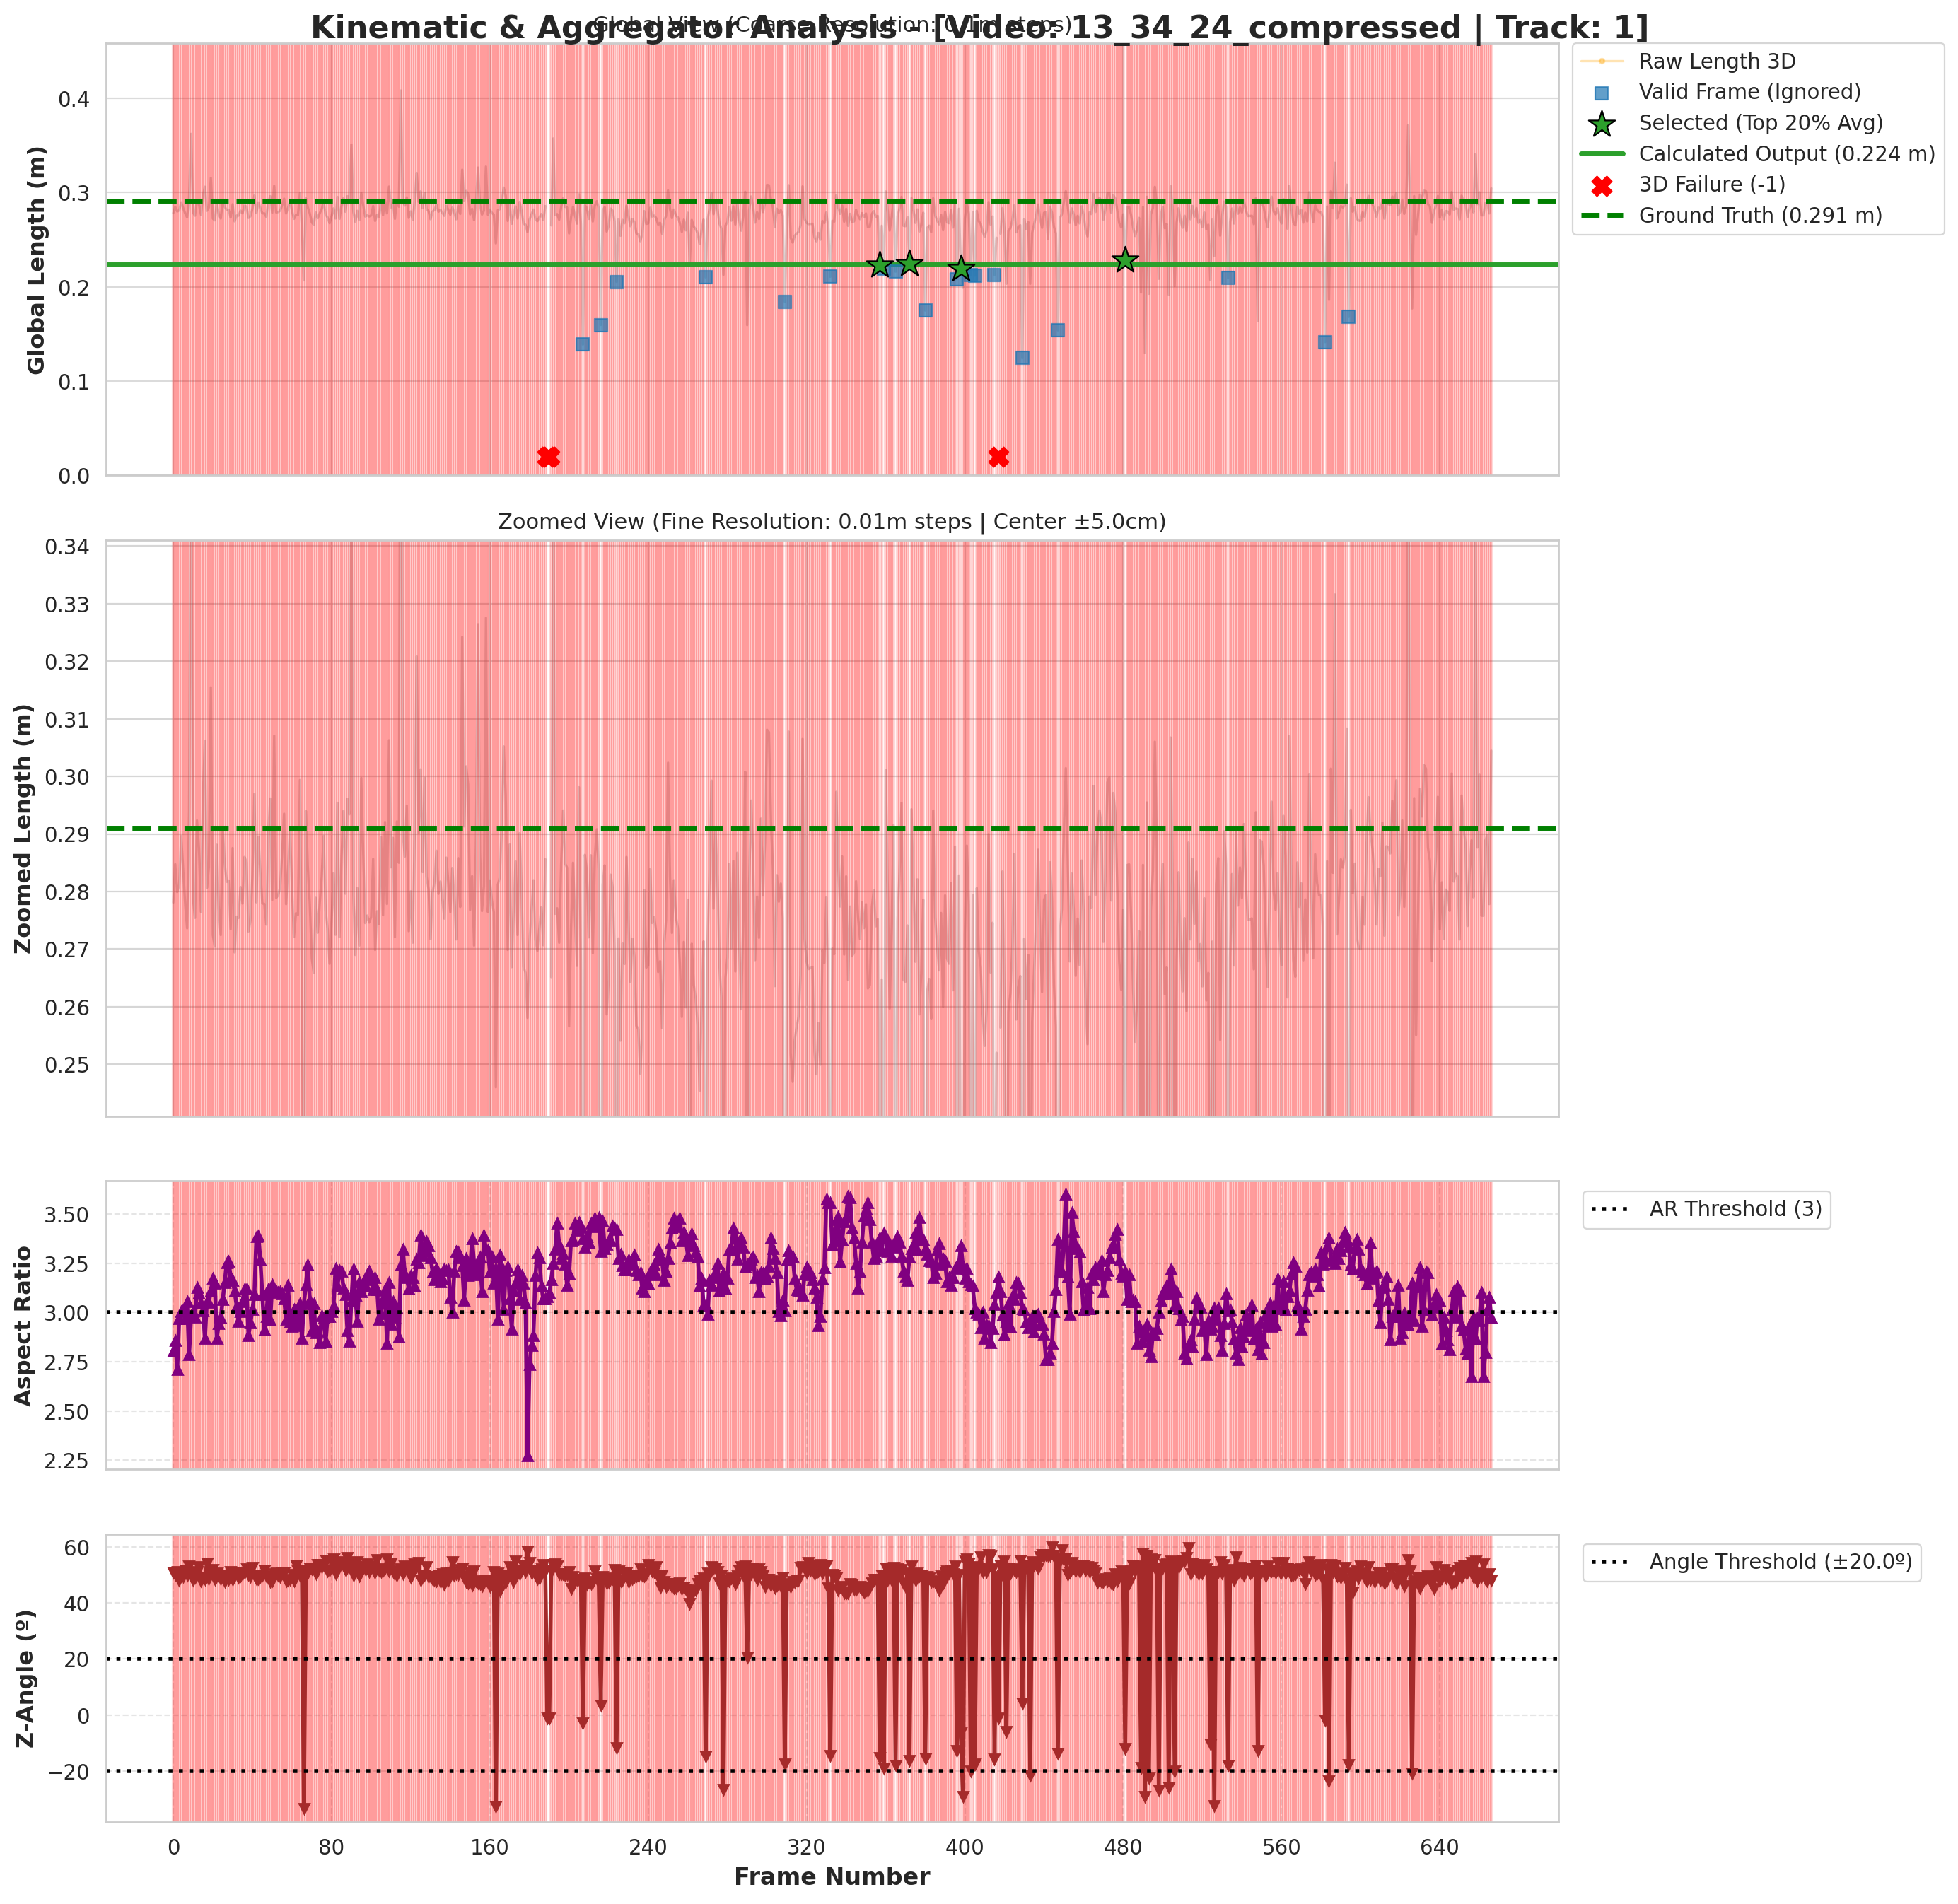

In [54]:
rutils.plot_track_evolution_detailed(df_raw_agg_2025_08_21, "13_34_24_compressed", 1, ar_thr=3, angle_thr=20.0)

In [24]:
df_raw_agg_2024_11_12[(df_raw_agg_2024_11_12["source_folder"] == "11_10_50_0") & (df_raw_agg_2024_11_12["track_id"] == -1)]

,video_day,source_folder,frame_id,class_name,object_id,track_id,is_3D_complete,in_image_borders,does_overlap,is_front_fish,...,fish_direction,elevation_deg,azimuth_deg,raw_length,filtered_length,spine_length,gt,abs_error_cm,rel_error_%,fish_dist_from_camera
375,2024_11_12,11_10_50_0,frame_8,0,255,-1,1,False,False,True,...,NaN,NaN,NaN,NaN,NaN,NaN,31.5,NaN,NaN,NaN
377,2024_11_12,11_10_50_0,frame_15,0,255,-1,1,False,False,True,...,NaN,NaN,NaN,NaN,NaN,NaN,31.5,NaN,NaN,NaN
391,2024_11_12,11_10_50_0,frame_29,0,255,-1,1,False,False,True,...,[ -0.55305 -0.06401 0.83069],56.218996,-171.315678,0.317581,0.318348,0.316453,31.5,0.334780,1.062793,1.599564
392,2024_11_12,11_10_50_0,frame_30,0,255,-1,1,False,False,True,...,[ -0.47474 -0.013102 0.88003],61.866096,-177.666040,0.332744,0.329194,0.316637,31.5,1.419433,4.506138,1.594793
393,2024_11_12,11_10_50_0,frame_31,0,255,-1,1,False,False,True,...,[ -0.36194 0.014751 0.93208],61.067630,-179.215706,0.489296,0.322779,0.312782,31.5,0.777868,2.469423,1.583742
440,2024_11_12,11_10_50_0,frame_99,0,255,-1,1,False,False,True,...,NaN,NaN,NaN,NaN,NaN,NaN,31.5,NaN,NaN,NaN
446,2024_11_12,11_10_50_0,frame_107,0,255,-1,1,False,False,True,...,[ -0.38013 0.1128 0.91803],-14.081441,96.014717,0.330086,0.088652,0.093684,31.5,22.634834,71.856615,1.966287
448,2024_11_12,11_10_50_0,frame_109,0,255,-1,1,False,False,True,...,[ -0.3824 0.26968 0.88377],12.512155,104.676604,0.364178,0.184451,0.178333,31.5,13.054935,41.444238,1.983479
450,2024_11_12,11_10_50_0,frame_118,0,255,-1,0,True,False,True,...,NaN,NaN,NaN,NaN,NaN,NaN,31.5,NaN,NaN,NaN
451,2024_11_12,11_10_50_0,frame_119,0,255,-1,0,True,False,True,...,NaN,NaN,NaN,NaN,NaN,NaN,31.5,NaN,NaN,NaN


In [21]:
display(df_base_noviembre.sort_values(by='abs_error_cm', ascending=False))

,video_day,source_folder,track_id,n_frames_validos,calculated_length_cm,gt_cm,abs_error_cm,mean_elevation_deg
19,2024_11_12,11_10_50_0,-1,5.0,15.893202,31.5,15.606798,7.140087
14,2024_11_12,11_00_27_0,21,5.0,29.229843,31.5,2.270157,12.900353
13,2024_11_12,11_00_27_0,12,13.0,32.999723,31.5,1.499723,-10.594451
3,2024_11_12,10_48_44_1,-1,6.0,30.176761,31.5,1.323239,-1.601370
0,2024_11_12,10_48_44_0,-1,13.0,30.195400,31.5,1.304600,1.777572
12,2024_11_12,11_00_27_0,1,12.0,32.759781,31.5,1.259781,-3.291797
2,2024_11_12,10_48_44_0,43,5.0,30.625299,31.5,0.874701,-7.515415
16,2024_11_12,11_08_39_0,20,5.0,30.669908,31.5,0.830092,3.256315
17,2024_11_12,11_08_39_0,31,14.0,30.724233,31.5,0.775767,-6.147942
7,2024_11_12,10_54_07_0,-1,9.0,30.750411,31.5,0.749589,5.684229


Calculating interaction between Aspect Ratio and Angle...


Evaluating Angles:   0%|          | 0/6 [00:00<?, ?it/s]

Evaluating Angles: 100%|██████████| 6/6 [00:03<00:00,  1.83it/s]


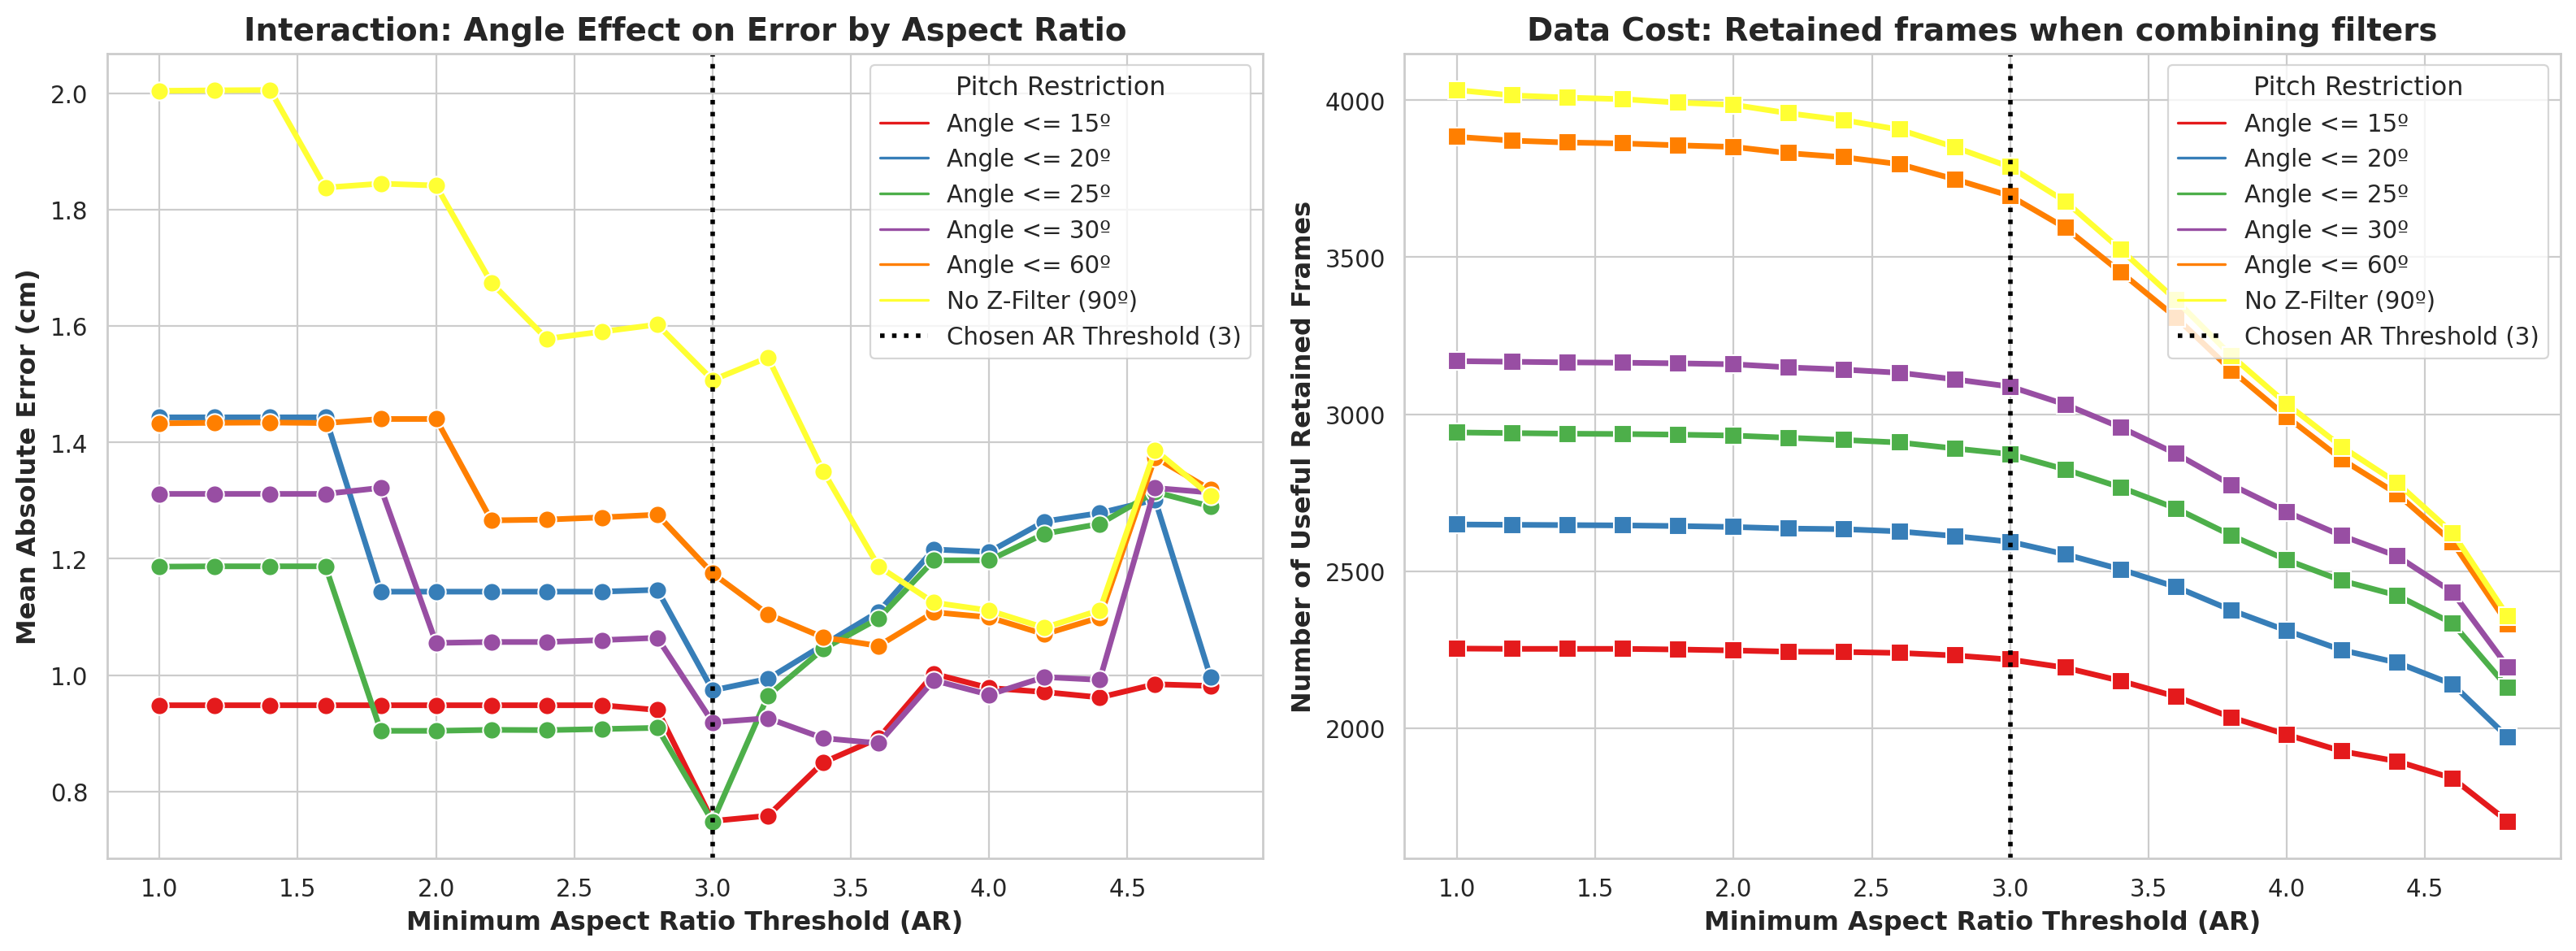

,Angle_Thr,AR_Thr,Error_cm,Frames,Tracks
0,Angle <= 15º,1.0,0.948286,2254,60
1,Angle <= 15º,1.2,0.948286,2253,60
2,Angle <= 15º,1.4,0.948286,2253,60
3,Angle <= 15º,1.6,0.948286,2253,60
4,Angle <= 15º,1.8,0.948286,2251,60
...,...,...,...,...,...
115,No Z-Filter (90º),4.0,1.111177,3033,74
116,No Z-Filter (90º),4.2,1.081445,2896,64
117,No Z-Filter (90º),4.4,1.111685,2781,59
118,No Z-Filter (90º),4.6,1.386906,2622,54


In [15]:
df_base =df_raw_agg_pool[
        # (df_raw['is_3D_complete'] == True) &
        (df_raw_agg_pool['in_image_borders'] == False) &
        (df_raw_agg_pool['does_overlap'] == False) &
        (df_raw_agg_pool['filtered_length'] > 0)
    ].copy()

rutils.plot_thresholds_interaction(df_base)

Calculating interaction between Aspect Ratio and Angle...


Evaluating Angles: 100%|██████████| 6/6 [00:01<00:00,  3.90it/s]


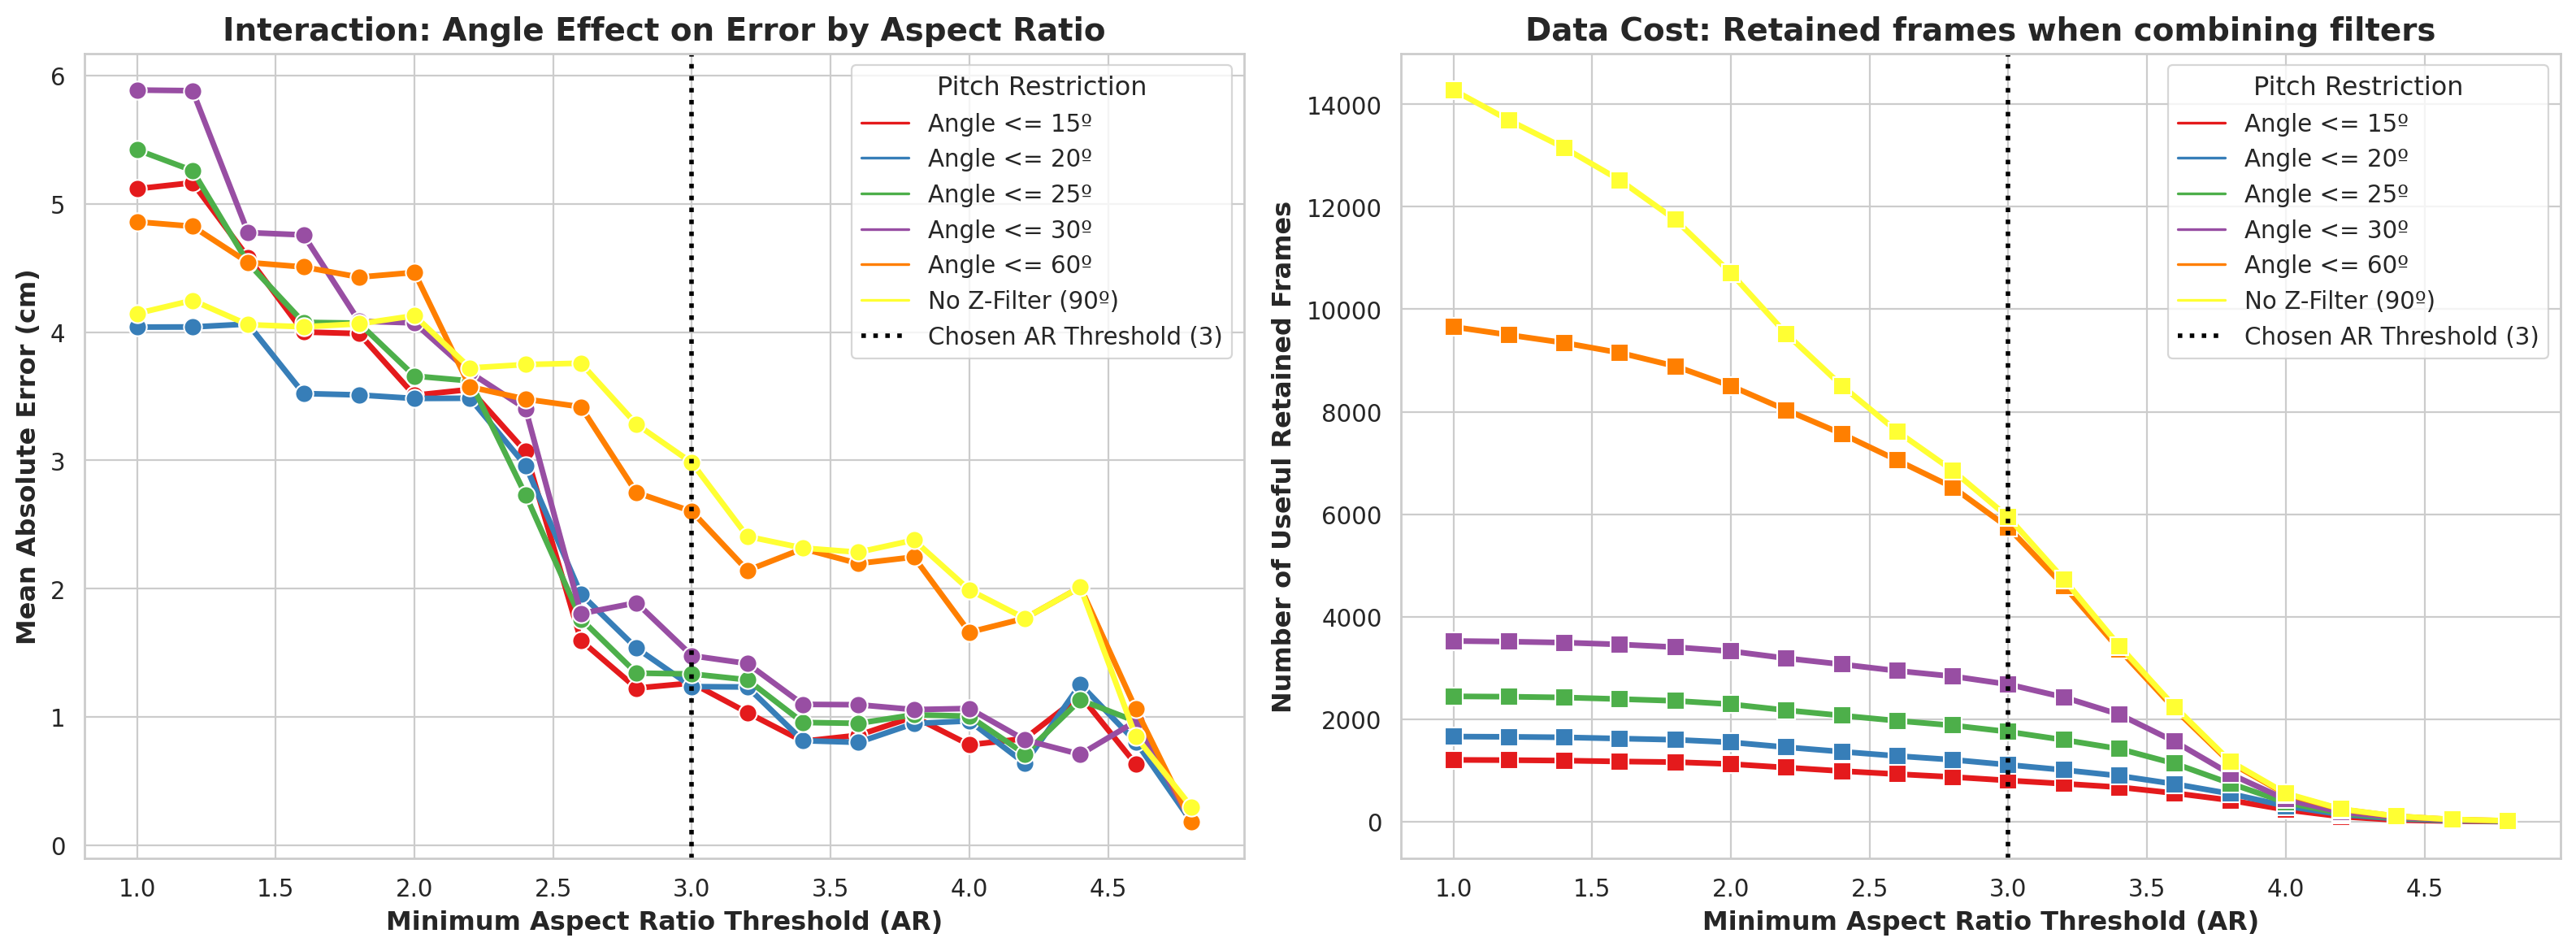

,Angle_Thr,AR_Thr,Error_cm,Frames,Tracks
0,Angle <= 15º,1.0,5.116553,1205,29
1,Angle <= 15º,1.2,5.163928,1200,29
2,Angle <= 15º,1.4,4.581759,1191,29
3,Angle <= 15º,1.6,4.000187,1174,28
4,Angle <= 15º,1.8,3.988311,1162,28
...,...,...,...,...,...
115,No Z-Filter (90º),4.0,1.990269,552,19
116,No Z-Filter (90º),4.2,1.768840,245,10
117,No Z-Filter (90º),4.4,2.012239,106,7
118,No Z-Filter (90º),4.6,0.846888,43,3


In [16]:
df_base =df_raw_agg_2025_08_21[
        # (df_raw['is_3D_complete'] == True) &
        (df_raw_agg_2025_08_21['in_image_borders'] == False) &
        (df_raw_agg_2025_08_21['does_overlap'] == False) &
        (df_raw_agg_2025_08_21['filtered_length'] > 0)
    ].copy()

rutils.plot_thresholds_interaction(df_base)

In [ ]:
df_raw_agg_2025_08_21

,video_day,source_folder,frame_id,class_name,object_id,track_id,is_3D_complete,in_image_borders,does_overlap,is_front_fish,...,fish_direction,elevation_deg,azimuth_deg,raw_length,filtered_length,spine_length,gt,abs_error_cm,rel_error_%,fish_dist_from_camera
0,12_09_03,2025_08_21,frame_0,0,255,1,-1,False,False,True,...,NaN,67.619721,37.106544,-1.0,0.322840,0.316668,29.1,3.184030,11.709446,1.663082
1,12_09_03,2025_08_21,frame_1,0,255,1,-1,False,False,True,...,NaN,66.080659,37.133779,-1.0,0.308119,0.328139,29.1,1.711855,6.615414,1.659265
2,12_09_03,2025_08_21,frame_2,0,255,1,-1,False,False,True,...,NaN,50.109826,25.106295,-1.0,0.249701,0.228324,29.1,4.129863,13.598142,1.693085
3,12_09_03,2025_08_21,frame_3,0,255,1,-1,False,False,True,...,NaN,58.247246,14.057908,-1.0,0.300613,0.282332,29.1,0.961328,4.018435,1.678158
4,12_09_03,2025_08_21,frame_4,0,255,1,-1,False,False,True,...,NaN,44.696387,13.541004,-1.0,0.257552,0.244369,29.1,3.344761,10.881526,1.710066
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15498,12_07_31,2025_08_21,frame_662,0,255,1,-1,False,False,True,...,NaN,79.294583,-50.546886,-1.0,0.340876,0.338881,29.1,4.987628,17.950270,1.795066
15499,12_07_31,2025_08_21,frame_663,0,255,1,-1,False,False,True,...,NaN,76.837679,-46.298834,-1.0,0.350149,0.356385,29.1,5.914872,21.158726,1.786328
15500,12_07_31,2025_08_21,frame_664,0,255,1,-1,False,False,True,...,NaN,77.656910,-44.845737,-1.0,0.344245,0.336567,29.1,5.324532,19.116027,1.783682
15501,12_07_31,2025_08_21,frame_665,0,255,1,-1,False,False,True,...,NaN,78.717863,-45.519965,-1.0,0.329868,0.334901,29.1,3.886777,14.141098,1.792683
